## Setup for EDA and time series 

In [60]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [61]:
# Importing required libraries
import requests
import pandas as pd
import csv
import numpy as np
from itertools import permutations

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Data Viz. 
import statsmodels.formula.api as smf
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.ndimage import gaussian_filter
from calendar import monthrange
from calendar import month_name
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import classification_report

from statsmodels.tsa.stattools import adfuller,kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.graphics.tsaplots import plot_pacf

from pmdarima.arima import auto_arima
import statsmodels.graphics.tsaplots as tsaplot
from statsmodels.tsa.holtwinters import Holt, ExponentialSmoothing, SimpleExpSmoothing


from statsmodels.tsa.statespace.sarimax import SARIMAX
#New Libraries
#from statsmodels.tsa.statespace.sarimax import SARIMAX
sns.set_style(
    style='darkgrid', 
    rc={'axes.facecolor': 'white', 'grid.color': '.8'}
)
NF_ORANGE = '#ff5a36'
NF_BLUE = '#163251'
cmaps_hex = ['#193251','#FF5A36','#696969', '#7589A2','#FF5A36', '#DB6668']
sns.set_palette(palette=cmaps_hex)
sns_c = sns.color_palette(palette=cmaps_hex)
%matplotlib inline
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100
import matplotlib.dates as mdates  


In [62]:
#from statsmodels.tsa.stattools import adfuller
#!pip install pmdarima --quiet
#import pmdarima as pm


### Columns
|Name                | Description                                                                   | Type     |Energy Source
|---------------------|-------------------------------------------------------------------------------|----------|----------|
| Area       |     Whole Germany                          |object   |     |
| Mtu     |                                  | object  |    |
| Biomass_mwh         |     Biomass                 | float64 |Renewable |
| Fossil_brown_coal_mwh      | Fossil brown coal              | float64 |Fossil  Fuels|
| Fossil_coal_derived_gas_mwh    |    Fossil coal derived gas       | float64 |Fossil  Fuels |
| Fossil_gas_mwh      |      Fossil gas                | float64 |Fossil  Fuels|
| Fossil_hard_coal_mwh     |      Fossil hard coal           | float64 |Fossil  Fuels|
| Fossil_oil_mwh      |       Fossil oil               | float64 |Fossil  Fuels|
| Fossil_oil_shale_mwh     |    Fossil oil shale             | float64 |Fossil  Fuels   |
| Fossil_peat_mwh     |   Fossil peat                    | float64 |Fossil  Fuels |
| Geothermal_mwh    |        Geothermal                | float64 |Renewable|
| Hydro_pumped_storage_aggregated_mwh  | Hydro pumped storage (generation)    | float64 |    |
| Hydro_pumped_storage_consumption_mwh   | Hydro pumped storage (consumption)| float64 |    |
| Hydro_run_of_river_and_poundage_mwh   | Hydro run of river and poundage   | float64 |Renewable|
| Hydro_water_reservoir_mwh  |    Hydro water reservoir             | float64 |Renewable|
| Marine_mwh     |   Marine                        | float64 |Renewable|
| Nuclear_mwh  |       Nuclear                       | float64 |Nuclear   |
| Other_mwh     |       Other                     | float64 |    |
| Other_renewable_mwh     |    Other renewable              | float64 |Renewable|
| Solar_mwh     |      Solar                      | float64 |Renewable |
| Waste_mwh    |     Waste                        | float64 |Renewable  |
| Wind_offshore_mwh    |  Wind offshore                   | float6  |Renewable |
| Wind_onshore_mwh   |      Wind onshore                 | float64 |Renewable  |
| Date                  |   Date(yyyy-mm-dd)                 | int64 |    |
| Hour        |Timesatmp of 'UTC+1' timezone                          | int64 |    |
| Total_energy_generation_mwh   | Total energy generation of Germany           | float64 |    |
| Total_other_renewable_mwh   | Total renewable energy generation (excluding solar)  of Germany           | float64 |    |


#### Dataframes details 
- res_df $\rightarrow$  Import  the original  data
- data_df_mwh  $\rightarrow$   Data in mwh units (This copy of original data)
- data_df_gwh  $\rightarrow$  Data in gwh units 
- data_df  $\rightarrow$  Contain the final preprocessing data in mwh/gwh units 
- df_dt is final dataframe for XG Boost regressor (only contain the 'datatime' and  'target' features)

### Units of Solar Energy production
- One kilowatt (kW) =  1,000 watts, 
- One megawatt (MW) =  1,000 kilowatts, 
- One gigawatt (GW) =  1,000 megawatts, 
- One terawatt (TW) =  1,000 gigawatts.

In [63]:
# Target columns   total_energy_generation_mwh, solar_mwh

In [64]:
# Import data
#This is data file of 20.07.2023
#res_df = pd.read_csv('data/result_20150101-20230716_cond2.csv')
# This is updated data file of 24.07.2023
res_df = pd.read_csv('data/transparency_20150101-20230716_hourly.csv')
res_df.head()

,area,mtu,biomass_mwh,fossil_brown_coal_mwh,fossil_coal_derived_gas_mwh,fossil_gas_mwh,fossil_hard_coal_mwh,fossil_oil_mwh,fossil_oil_shale_mwh,fossil_peat_mwh,...,nuclear_mwh,other_mwh,other_renewable_mwh,solar_mwh,waste_mwh,wind_offshore_mwh,wind_onshore_mwh,date,hour,total_energy_generation_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,10710.50,4567.50,123.0,0.0,298.25,521.00,8849.75,20150101,0,51459.25
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,11086.25,4596.25,112.5,0.0,295.00,520.75,9046.50,20150101,1,49988.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,11026.25,4713.75,83.0,0.0,288.25,519.00,9196.00,20150101,2,49265.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,11027.75,4740.25,76.0,0.0,303.50,522.50,9146.75,20150101,3,48538.00
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,10962.25,4726.50,76.0,0.0,303.00,524.25,9204.00,20150101,4,48630.00


In [65]:
#res_df.dtypes

In [66]:
res_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74879 entries, 0 to 74878
Data columns (total 26 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   area                                  74879 non-null  object 
 1   mtu                                   74879 non-null  object 
 2   biomass_mwh                           74879 non-null  float64
 3   fossil_brown_coal_mwh                 74879 non-null  float64
 4   fossil_coal_derived_gas_mwh           74879 non-null  float64
 5   fossil_gas_mwh                        74879 non-null  float64
 6   fossil_hard_coal_mwh                  74879 non-null  float64
 7   fossil_oil_mwh                        74879 non-null  float64
 8   fossil_oil_shale_mwh                  74879 non-null  float64
 9   fossil_peat_mwh                       74879 non-null  float64
 10  geothermal_mwh                        74879 non-null  float64
 11  hydro_pumped_st

In [67]:
# Cerate a working data frame
#importing data in original units 
data_df_mwh = res_df.copy()
#data_df_mwh.head()

In [68]:
#ycol_all_renw = ['total_energy_generation_mwh', 'solar_mwh', 'solar/energy_total','diff_total_energy_and_solar_mwh',
#             'wind_onshore_mwh','wind_offshore_mwh','waste_mwh','Solar_mwh','other_renewable_mwh',  
#             'marine_mwh','hydro_run_of_river_and_poundage_mwh','hydro_water_reservoir_mwh','geothermal_mwh']
#
#ycol_renw = ['wind_onshore_mwh','wind_offshore_mwh','waste_mwh','other_renewable_mwh',  
#             'marine_mwh','hydro_run_of_river_and_poundage_mwh','hydro_water_reservoir_mwh','geothermal_mwh']


#### Here we add new columns to data frame 

In [69]:

# Here we add new columns to data frame 
data_df_mwh['solar/Total_energy'] =  (data_df_mwh['solar_mwh']/data_df_mwh['total_energy_generation_mwh'])*100
data_df_mwh['diff_total_energy_and_solar_mwh'] =  data_df_mwh['total_energy_generation_mwh'] - data_df_mwh['solar_mwh']

# Total renewable energy column other than solar 
data_df_mwh['total_other_renewable_mwh'] = data_df_mwh['wind_onshore_mwh'] + data_df_mwh['wind_offshore_mwh'] + data_df_mwh['waste_mwh']
+ data_df_mwh['other_renewable_mwh'] + data_df_mwh['marine_mwh'] + data_df_mwh['hydro_run_of_river_and_poundage_mwh'] + data_df_mwh['hydro_water_reservoir_mwh'] + data_df_mwh['geothermal_mwh']
data_df_mwh.head()


,area,mtu,biomass_mwh,fossil_brown_coal_mwh,fossil_coal_derived_gas_mwh,fossil_gas_mwh,fossil_hard_coal_mwh,fossil_oil_mwh,fossil_oil_shale_mwh,fossil_peat_mwh,...,solar_mwh,waste_mwh,wind_offshore_mwh,wind_onshore_mwh,date,hour,total_energy_generation_mwh,solar/Total_energy,diff_total_energy_and_solar_mwh,total_other_renewable_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,0.0,298.25,521.00,8849.75,20150101,0,51459.25,0.0,51459.25,9669.00
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,0.0,295.00,520.75,9046.50,20150101,1,49988.25,0.0,49988.25,9862.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,0.0,288.25,519.00,9196.00,20150101,2,49265.25,0.0,49265.25,10003.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,0.0,303.50,522.50,9146.75,20150101,3,48538.00,0.0,48538.00,9972.75
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,0.0,303.00,524.25,9204.00,20150101,4,48630.00,0.0,48630.00,10031.25


#### We capitalize the columns names

In [70]:
##  Capitalize the columns names
data_df_mwh.columns = [col.capitalize() for col in data_df_mwh.columns]
# Print the dataframe
data_df_mwh.head()

,Area,Mtu,Biomass_mwh,Fossil_brown_coal_mwh,Fossil_coal_derived_gas_mwh,Fossil_gas_mwh,Fossil_hard_coal_mwh,Fossil_oil_mwh,Fossil_oil_shale_mwh,Fossil_peat_mwh,...,Solar_mwh,Waste_mwh,Wind_offshore_mwh,Wind_onshore_mwh,Date,Hour,Total_energy_generation_mwh,Solar/total_energy,Diff_total_energy_and_solar_mwh,Total_other_renewable_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,0.0,298.25,521.00,8849.75,20150101,0,51459.25,0.0,51459.25,9669.00
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,0.0,295.00,520.75,9046.50,20150101,1,49988.25,0.0,49988.25,9862.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,0.0,288.25,519.00,9196.00,20150101,2,49265.25,0.0,49265.25,10003.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,0.0,303.50,522.50,9146.75,20150101,3,48538.00,0.0,48538.00,9972.75
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,0.0,303.00,524.25,9204.00,20150101,4,48630.00,0.0,48630.00,10031.25


## Format Data & Feature Engineering

The dataset includes a timestamp. It might be interesting to have a look at additional features like for example `month`, `day`, `day of the year`, and `ho

In [71]:
#data_df_mwh.columns

#### Unit conversion from 'mwh' to 'gwh' 

In [72]:
data_df_gwh = data_df_mwh.copy()

In [73]:
#data_df_mwh['Marine_mwh']
data_df_gwh.columns

Index(['Area', 'Mtu', 'Biomass_mwh', 'Fossil_brown_coal_mwh',
       'Fossil_coal_derived_gas_mwh', 'Fossil_gas_mwh', 'Fossil_hard_coal_mwh',
       'Fossil_oil_mwh', 'Fossil_oil_shale_mwh', 'Fossil_peat_mwh',
       'Geothermal_mwh', 'Hydro_pumped_storage_aggregated_mwh',
       'Hydro_pumped_storage_consumption_mwh',
       'Hydro_run_of_river_and_poundage_mwh', 'Hydro_water_reservoir_mwh',
       'Marine_mwh', 'Nuclear_mwh', 'Other_mwh', 'Other_renewable_mwh',
       'Solar_mwh', 'Waste_mwh', 'Wind_offshore_mwh', 'Wind_onshore_mwh',
       'Date', 'Hour', 'Total_energy_generation_mwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_mwh', 'Total_other_renewable_mwh'],
      dtype='object')

In [74]:
# Here we convert  unit from mwh to gwh 
for col in ['Biomass_mwh', 'Fossil_brown_coal_mwh',
       'Fossil_coal_derived_gas_mwh', 'Fossil_gas_mwh', 'Fossil_hard_coal_mwh',
       'Fossil_oil_mwh', 'Fossil_oil_shale_mwh', 'Fossil_peat_mwh',
       'Geothermal_mwh', 'Hydro_pumped_storage_aggregated_mwh',
       'Hydro_pumped_storage_consumption_mwh',
       'Hydro_run_of_river_and_poundage_mwh', 'Hydro_water_reservoir_mwh',
       'Marine_mwh', 'Nuclear_mwh', 'Other_mwh', 'Other_renewable_mwh',
       'Solar_mwh', 'Waste_mwh', 'Wind_offshore_mwh', 'Wind_onshore_mwh','Total_energy_generation_mwh', 'Diff_total_energy_and_solar_mwh', 'Total_other_renewable_mwh']:
       data_df_gwh[col] =  data_df_gwh[col]/1000.

In [75]:
# Here we rename columns from *_mwh to *_gwh
for col in data_df_gwh.columns:
       data_df_gwh.rename(columns={col:col.replace('mwh','gwh')},inplace=True)

In [76]:
#ycol_all_renw = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/energy_total','Diff_total_energy_and_solar_gwh',
#             'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh','Other_renewable_gwh',  'Total_other_renewable_gwh'
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']

#ycol_renw = ['Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Other_renewable_gwh',  'Total_other_renewable_gwh'
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']


In [77]:
data_df_gwh.head()    

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Solar_gwh,Waste_gwh,Wind_offshore_gwh,Wind_onshore_gwh,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,0.0,0.29825,0.52100,8.84975,20150101,0,51.45925,0.0,51.45925,9.66900
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,0.0,0.29500,0.52075,9.04650,20150101,1,49.98825,0.0,49.98825,9.86225
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,0.0,0.28825,0.51900,9.19600,20150101,2,49.26525,0.0,49.26525,10.00325
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,0.0,0.30350,0.52250,9.14675,20150101,3,48.53800,0.0,48.53800,9.97275
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,0.0,0.30300,0.52425,9.20400,20150101,4,48.63000,0.0,48.63000,10.03125


#### 'data_df' set the unit of final processing data

In [78]:

data_df= data_df_gwh.copy()

In [79]:
data_df.head()

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Solar_gwh,Waste_gwh,Wind_offshore_gwh,Wind_onshore_gwh,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,0.0,0.29825,0.52100,8.84975,20150101,0,51.45925,0.0,51.45925,9.66900
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,0.0,0.29500,0.52075,9.04650,20150101,1,49.98825,0.0,49.98825,9.86225
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,0.0,0.28825,0.51900,9.19600,20150101,2,49.26525,0.0,49.26525,10.00325
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,0.0,0.30350,0.52250,9.14675,20150101,3,48.53800,0.0,48.53800,9.97275
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,0.0,0.30300,0.52425,9.20400,20150101,4,48.63000,0.0,48.63000,10.03125


In [80]:
data_df['Date'] = pd.to_datetime(data_df['Date'], format='%Y%m%d')
# Extract year, month and date from the datetime object
data_df['Year'] = data_df['Date'].dt.year
data_df['Month'] = data_df['Date'].dt.month
data_df['Day'] = data_df['Date'].dt.day
data_df['Dayofyear'] = data_df['Date'].dt.dayofyear
data_df.head()

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh,Year,Month,Day,Dayofyear
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,2015-01-01,0,51.45925,0.0,51.45925,9.66900,2015,1,1,1
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,2015-01-01,1,49.98825,0.0,49.98825,9.86225,2015,1,1,1
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,2015-01-01,2,49.26525,0.0,49.26525,10.00325,2015,1,1,1
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,2015-01-01,3,48.53800,0.0,48.53800,9.97275,2015,1,1,1
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,2015-01-01,4,48.63000,0.0,48.63000,10.03125,2015,1,1,1


## Visualize the Data

Let us start by plotting the temperature data over time. We can either use the hourly development or aggregate the feature by day to get a less dense plot. 

In [81]:
##data_df.columns

In [82]:
#data_df.isnull().sum()
#data_df = data_df.dropna()

- The target is fixed here. We can run the cell for any desirable y-axis data

In [83]:
#### Potential targets  (It corresponds to the rename column names.)
#title_main = 'Solar_gw' # General title of plots files
#main_0  = 'Total_energy_generation_gwh' # This is only for energy
main_0  = 'Solar_gwh' # for all other columns
title_main = main_0.replace('_', ' ').replace('gwh', 'energy generation')# for all other columns
#title_main = main_0.replace('_', ' ').replace('gwh', 'in GWh')# This is only for energy
print(title_main)

#### In units of mwh
#target = 'Total_energy_generation_mwh'
#target ='Solar_mwh'
#target = 'Solar/energy_total'
#target = 'Other_renewable_mwh'
#target = 'Diff_tenergy_solar_mwh'
#target = 'Total_other_renewable_mwh'

#set  the ylabel
#ylable_0  = target.replace('_mwh', '(mwh)')
#ylable_target  = ylable_0.replace('_', ' ')
#print(ylable_target)


#### In units of gwh
#target = 'Total_energy_generation_gwh'
target ='Solar_gwh'
#target = 'Solar/energy_total'
#target = 'Other_renewable_gwh'
#target = 'Diff_tenergy_solar_gwh'
#target = 'Total_other_renewable_gwh' 

# here we set the ylabel
ylable_0  = target.replace('_gwh', ' energy generation (GWh)')
ylable_target  = ylable_0.replace('_', ' ')
print(ylable_target)


Solar energy generation
Solar energy generation (GWh)


### Here we set the function for line plot  

In [84]:
def simple_lineplot(df, y, x='Date',time='Year'):
    fig, ax = plt.subplots()
    sns.lineplot(x=x, y=y, data=df, ax=ax)
   # try:
   #     sns.lineplot(x=x, y=y, data=df, ax=ax)
   # except:
   #     sns.lineplot(x=x, y=y, data=df, ax=ax)
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'energy in (GWh)'), ylabel=ylable_target0, xlabel=time);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)


def average_lineplot(df, y, x='Date', time='Year', group=''):
    grouped_df = df \
        .groupby([x, time, group], as_index=False)\
        .agg({y: np.mean}) \
        .set_index(x)

    fig, ax = plt.subplots()
    try:
        sns.lineplot(x=time, y=y, data=grouped_df, hue=group, ax=ax, palette='Set1')
    except:
        sns.lineplot(x=time, y=y, data=grouped_df, hue=group, ax=ax, palette='Set1')
    ylable_00  = y.replace('_gwh', 'energy in (GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'energy in GWh'), ylabel=ylable_target0);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)


def average_lineplot_no_group(df, y, x='Date', time='Year'):
    grouped_df = df \
        .groupby([x, time], as_index=False)\
        .agg({y: np.mean}) \
        .set_index(x)

    fig, ax = plt.subplots()
    sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, color='#33658A')
    ylable_00  = y.replace('_gwh', ' energy in (GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)
    plt.show()



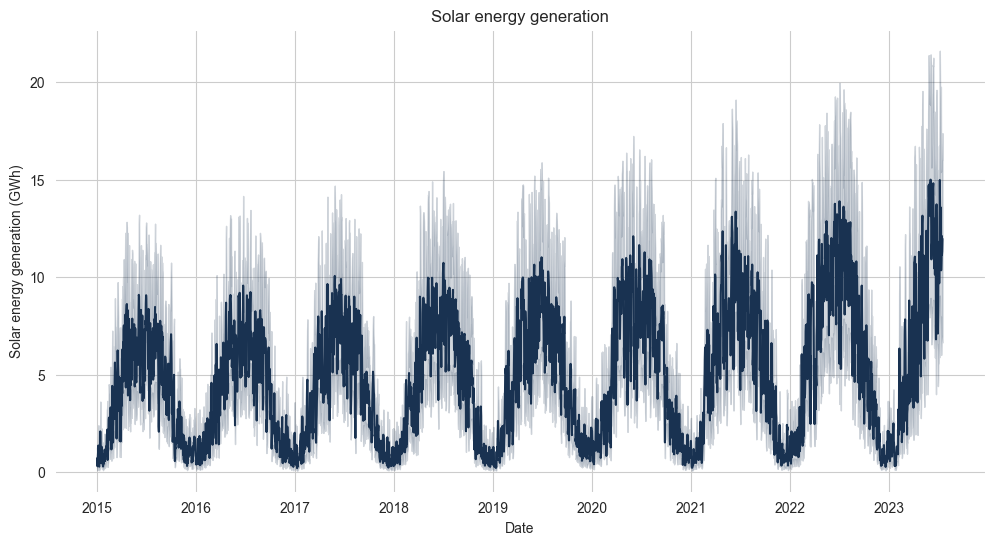

In [85]:
## Energy development over year (time)
fig, ax = plt.subplots()
sns.lineplot(x='Date', y=target, data=data_df, ax=ax)
ax.set(title=title_main, ylabel= ylable_target);

In [86]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    simple_lineplot(df=data_df, y=col, x="Date", time='Year')

In [87]:
data_df.columns

Index(['Area', 'Mtu', 'Biomass_gwh', 'Fossil_brown_coal_gwh',
       'Fossil_coal_derived_gas_gwh', 'Fossil_gas_gwh', 'Fossil_hard_coal_gwh',
       'Fossil_oil_gwh', 'Fossil_oil_shale_gwh', 'Fossil_peat_gwh',
       'Geothermal_gwh', 'Hydro_pumped_storage_aggregated_gwh',
       'Hydro_pumped_storage_consumption_gwh',
       'Hydro_run_of_river_and_poundage_gwh', 'Hydro_water_reservoir_gwh',
       'Marine_gwh', 'Nuclear_gwh', 'Other_gwh', 'Other_renewable_gwh',
       'Solar_gwh', 'Waste_gwh', 'Wind_offshore_gwh', 'Wind_onshore_gwh',
       'Date', 'Hour', 'Total_energy_generation_gwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_gwh', 'Total_other_renewable_gwh', 'Year',
       'Month', 'Day', 'Dayofyear'],
      dtype='object')

In [88]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot_no_group(df=data_df, y=col, x="Date", time='Year')

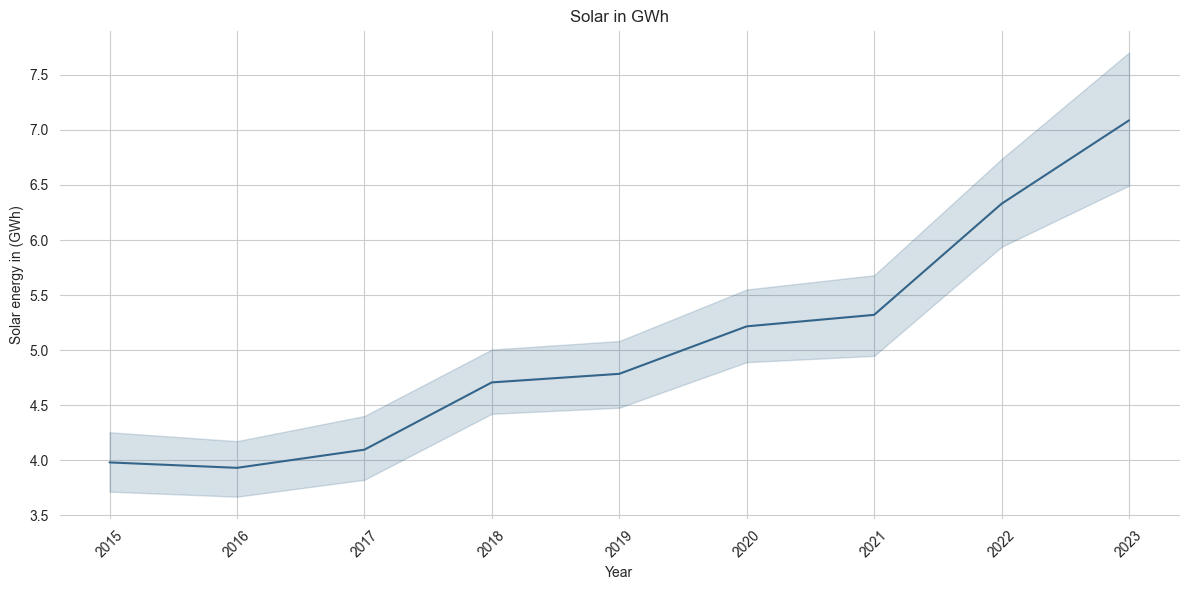

In [89]:
average_lineplot_no_group(df=data_df, y= target, x="Date", time='Year')

In [90]:
# Aggregate Energy_mwh or Solar_mwh by day
daily_data_df = data_df \
    .groupby(['Date', 'Year', 'Month', 'Day', 'Dayofyear', 'Hour'], as_index=False)\
    .agg({target: np.sum}) \
    .set_index('Date')

In [91]:
daily_data_df

,Year,Month,Day,Dayofyear,Hour,Solar_gwh
Date,,,,,,
2015-01-01,2015,1,1,1,0,0.00000
2015-01-01,2015,1,1,1,1,0.00000
2015-01-01,2015,1,1,1,2,0.00000
2015-01-01,2015,1,1,1,3,0.00000
2015-01-01,2015,1,1,1,4,0.00000
...,...,...,...,...,...,...
2023-07-17,2023,7,17,198,18,10.08425
2023-07-17,2023,7,17,198,19,4.72400
2023-07-17,2023,7,17,198,20,1.51125


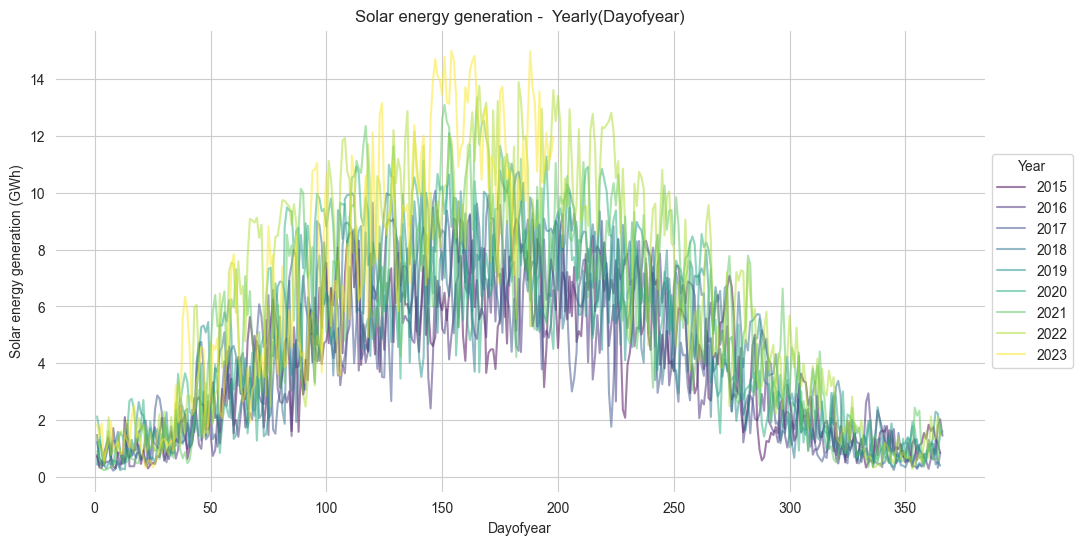

In [92]:
# Plot yearly seasonality
fig, ax = plt.subplots() 

pd.pivot_table(data=daily_data_df[['Year', 'Dayofyear', target]], index='Dayofyear', columns='Year') \
    [target] \
    .plot(cmap='viridis', alpha=0.5, ax=ax)

ax.legend(title='Year', loc='center left', bbox_to_anchor=(1, 0.5))
ax.set(title= title_main +' '+'-'+' ' + ' ' +'Yearly(Dayofyear)', ylabel=ylable_target);
#fig.savefig("visualisations/total_energy_generation_mwh.png",dpi=300)

In [93]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot(df=data_df, y=col, x='Date', time='Dayofyear', group='Year')

In [94]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr =  ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh','Other_renewable_gwh',  
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot(df=data_df, y=col, x='Date', time='Month', group='Year')

In [95]:
#data_df.columns

In [96]:
df_c = data_df.copy()

In [97]:
#df_c.columns

In [98]:
def combine_date_and_time(df, date_column='Date', time_column='Hour', target_column=target):
    # Convert 'Date' column to datetime format
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Combine 'Date' and 'Hour' columns to create the 'Datetime' column
    df['Datetime'] = df.apply(lambda row: row[date_column] + pd.Timedelta(hours=row[time_column]), axis=1)
    
    # Select the desired columns for the final DataFrame
    df_result  = df[['Datetime', target_column]]
    
    return df_result

In [99]:
df_dt = combine_date_and_time(df_c, date_column='Date', time_column='Hour', target_column=target)

In [100]:
df_dt.columns

Index(['Datetime', 'Solar_gwh'], dtype='object')

In [101]:
df_dt.head()

,Datetime,Solar_gwh
0,2015-01-01 00:00:00,0.0
1,2015-01-01 01:00:00,0.0
2,2015-01-01 02:00:00,0.0
3,2015-01-01 03:00:00,0.0
4,2015-01-01 04:00:00,0.0


In [122]:

#df_c = data_df.copy()
#df_c = data_df[['Date',  target]]
#df_dt = df_dt.set_index('Datetime')
#df_dt.plot(style = '-', figsize = (15,5), color='#1f76b4')

## Train & Test split

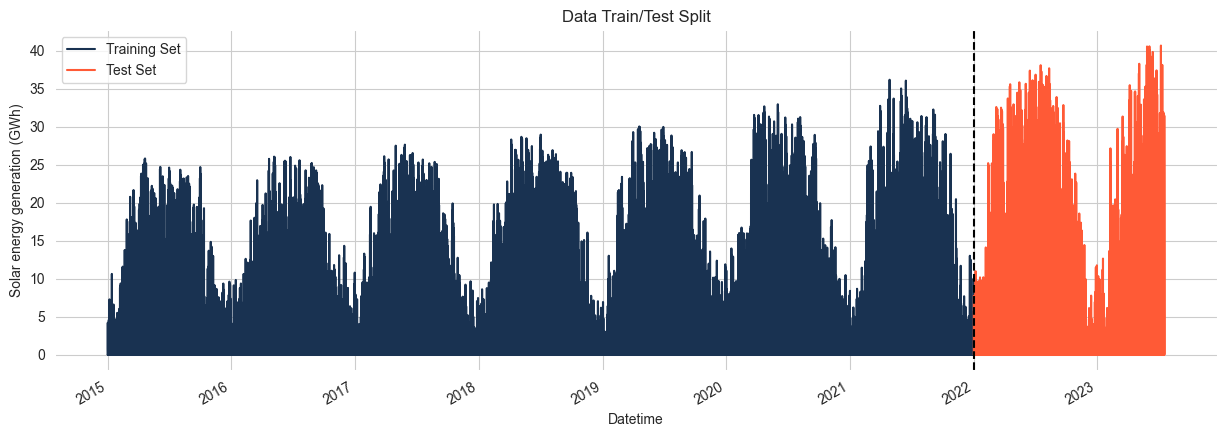

In [103]:
#df_c = pd.DataFrame(df_c.index)
#df_c.index
train =  df_dt.loc[df_dt.index < '2022-01-1']
test =  df_dt.loc[df_dt.index >= '2022-01-1']
fig, ax = plt.subplots(figsize=(15,5))
train.plot(ax=ax, label = 'Training Set', title= 'Data Train/Test Split')
test.plot (ax=ax, ylabel=ylable_target, label = 'Test Set')
ax.axvline('2022-01-1', color = 'black', ls= '--')
ax.legend(['Training Set','Test Set'])
#ax.ylabel(target)
plt.show()

In [105]:
#df_dt.loc[(df_dt.index > '2023-01-01') & (df_dt.index < '2023-12-01') ].plot(figsize=(15,5), ylabel=ylable_target, title= 'Data of last year', label = '2023 data')
#ax.legend(['2023 data'])
#plt.show()

In [106]:
def create_features(df):
    """
    create time series features based on time series index 
    """
    df['Hour'] = df.index.hour
    df['Year'] = df.index.year
    df['Month'] = df.index.month
   # df['Week'] = df.index.week
    df['Day'] = df.index.day
    #df['Dayofyear'] = df.index.dayofyear
    return df


In [107]:
df_dt = create_features(df_dt)
df_dt.head()

,Solar_gwh,Hour,Year,Month,Day
Datetime,,,,,
2015-01-01 00:00:00,0.0,0,2015,1,1
2015-01-01 01:00:00,0.0,1,2015,1,1
2015-01-01 02:00:00,0.0,2,2015,1,1
2015-01-01 03:00:00,0.0,3,2015,1,1
2015-01-01 04:00:00,0.0,4,2015,1,1


Text(0, 0.5, 'Solar energy generation (GWh)')

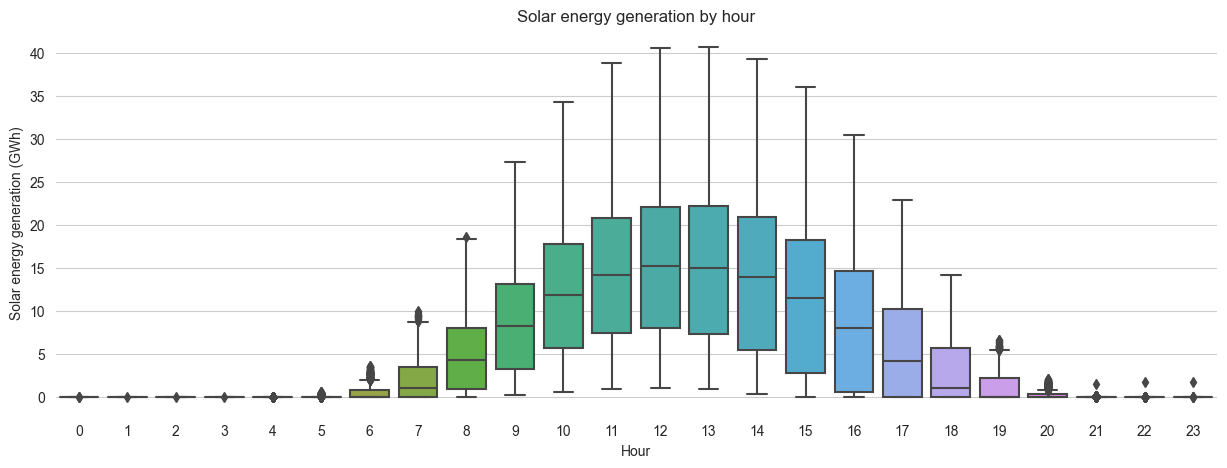

In [108]:
fig, ax = plt.subplots(figsize=(15,5))
sns.boxplot (data=df_dt, x= 'Hour', y =target)
ax.set_title( title_main + '' + ' ' 'by hour')
ax.set_ylabel(ylable_target)

In [109]:
#fig, ax = plt.subplots(figsize=(15,5))
#sns.boxplot (data=df_dt, x= 'Month', y =target)
#ax.set_title(title_main + '' + ' ' 'by month')
#ax.set_ylabel(ylable_target)

In [110]:
#fig, ax = plt.subplots(figsize=(15,5))
#sns.boxplot (data=df_dt, x= 'Day', y =target)
#ax.set_title(title_main + '' + ' ' 'by day')
#ax.set_ylabel(ylable_target)

## Feature Creations

In [111]:
features= ['Hour','Year', 'Month', 'Day']# 

features1= ['Year', 'Month', 'Day']# 

In [112]:
train = create_features(train)
test = create_features(test)
#train.head()

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_16399/30602683.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Hour'] = df.index.hour
/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_16399/30602683.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year'] = df.index.year
/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_16399/30602683.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_ind

#### XGboost with  MinMaxScaler() [for features features= ['Hour','Year', 'Month', 'Day']]

[0]	validation_0-rmse:6.07189	validation_1-rmse:9.43243
[1]	validation_0-rmse:4.70839	validation_1-rmse:7.82053
[2]	validation_0-rmse:3.78429	validation_1-rmse:6.71816
[3]	validation_0-rmse:3.20210	validation_1-rmse:5.88422


[4]	validation_0-rmse:2.83280	validation_1-rmse:5.23448
[5]	validation_0-rmse:2.61576	validation_1-rmse:4.80432
[6]	validation_0-rmse:2.49316	validation_1-rmse:4.55444
[7]	validation_0-rmse:2.42178	validation_1-rmse:4.34957
[8]	validation_0-rmse:2.36885	validation_1-rmse:4.21652
[9]	validation_0-rmse:2.33569	validation_1-rmse:4.09898
[10]	validation_0-rmse:2.30561	validation_1-rmse:4.02046
[11]	validation_0-rmse:2.28980	validation_1-rmse:3.93943
[12]	validation_0-rmse:2.27215	validation_1-rmse:3.87805


/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


[13]	validation_0-rmse:2.26250	validation_1-rmse:3.85456
[14]	validation_0-rmse:2.23834	validation_1-rmse:3.81335
[15]	validation_0-rmse:2.22837	validation_1-rmse:3.80147
[16]	validation_0-rmse:2.22042	validation_1-rmse:3.79602
[17]	validation_0-rmse:2.20575	validation_1-rmse:3.80458
[18]	validation_0-rmse:2.19305	validation_1-rmse:3.79441
[19]	validation_0-rmse:2.18307	validation_1-rmse:3.79713
[20]	validation_0-rmse:2.16814	validation_1-rmse:3.79242
[21]	validation_0-rmse:2.15534	validation_1-rmse:3.79096
[22]	validation_0-rmse:2.14612	validation_1-rmse:3.78572
[23]	validation_0-rmse:2.14072	validation_1-rmse:3.79148
[24]	validation_0-rmse:2.13387	validation_1-rmse:3.78972
[25]	validation_0-rmse:2.12630	validation_1-rmse:3.78957
[26]	validation_0-rmse:2.11388	validation_1-rmse:3.79086
[27]	validation_0-rmse:2.10191	validation_1-rmse:3.79192
[28]	validation_0-rmse:2.09373	validation_1-rmse:3.80067
[29]	validation_0-rmse:2.08466	validation_1-rmse:3.80180
[30]	validation_0-rmse:2.07233	

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_13075/1932592242.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediction'] = xgb_reg.predict(X_test_scaled)


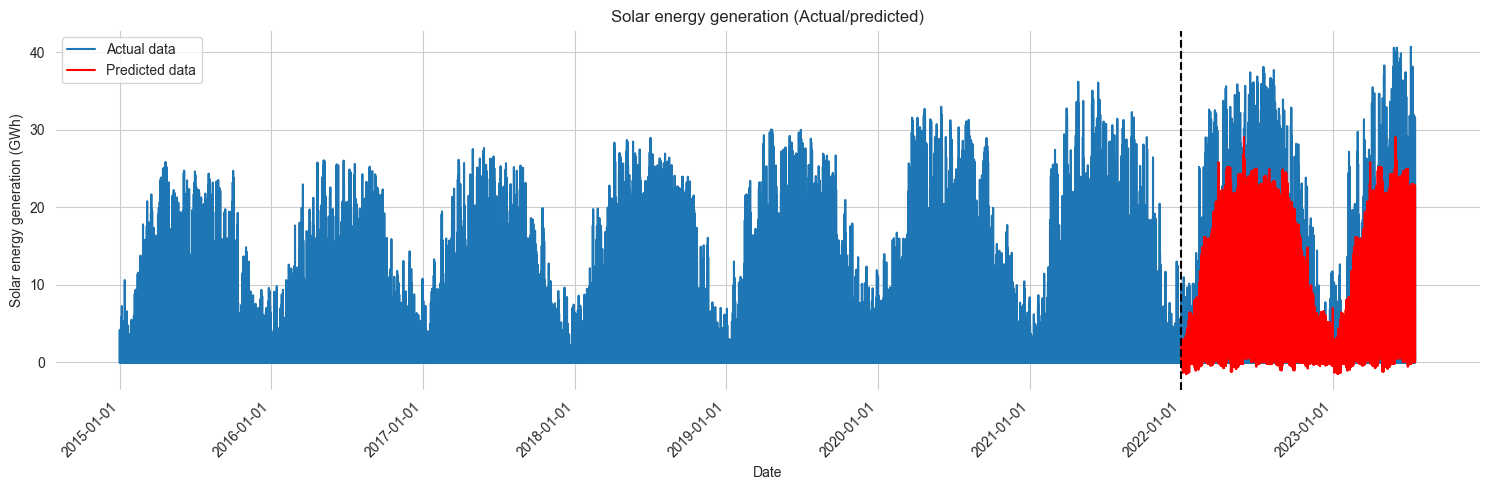

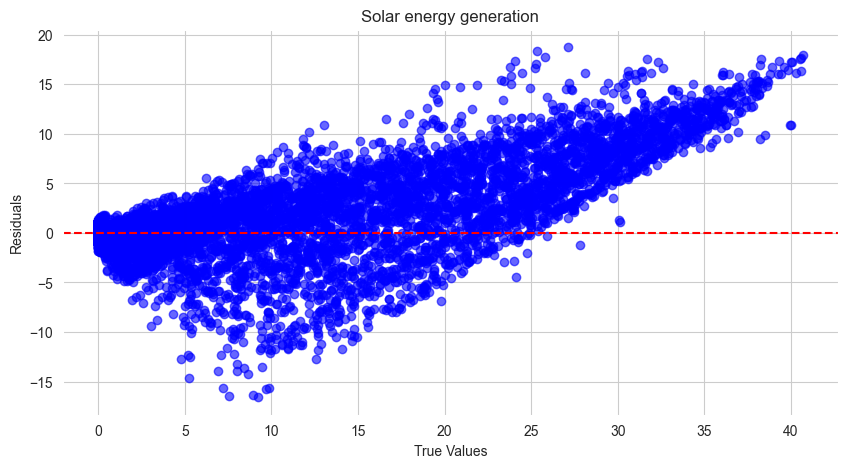

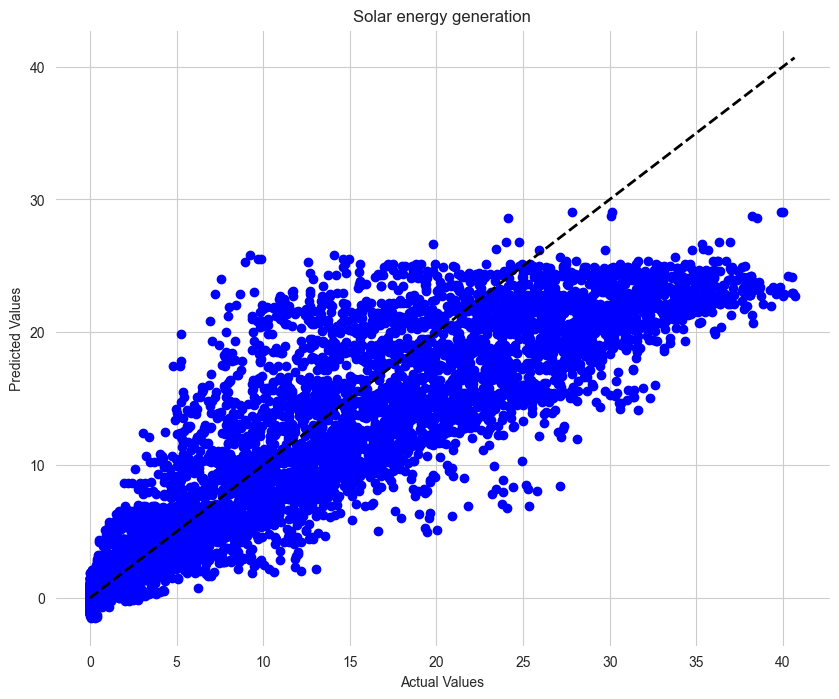

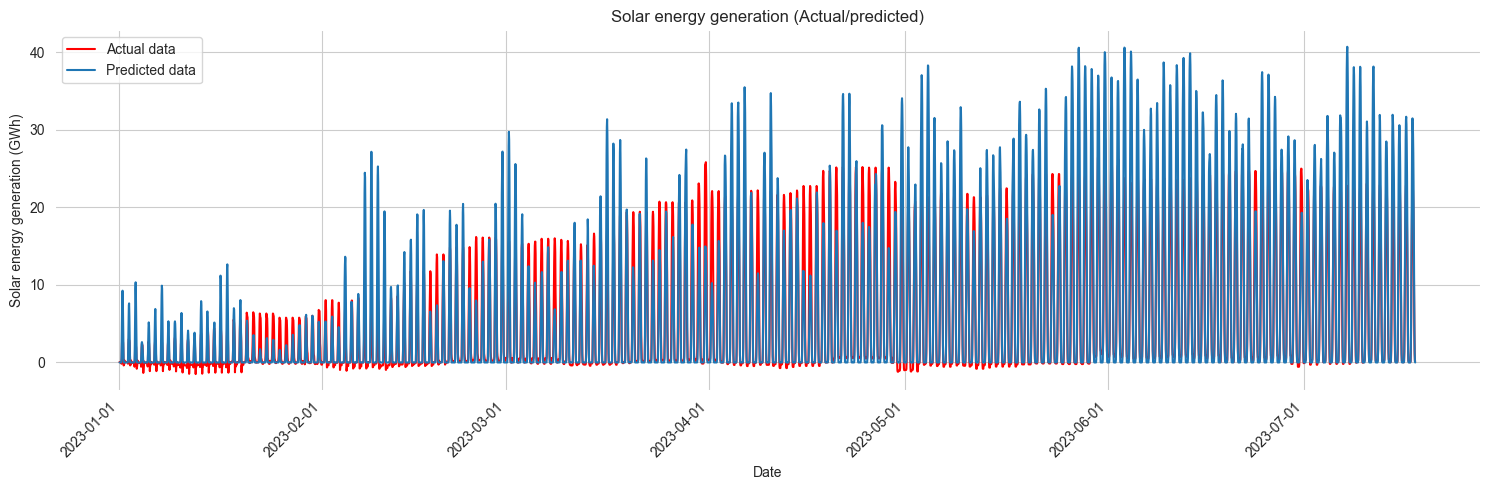

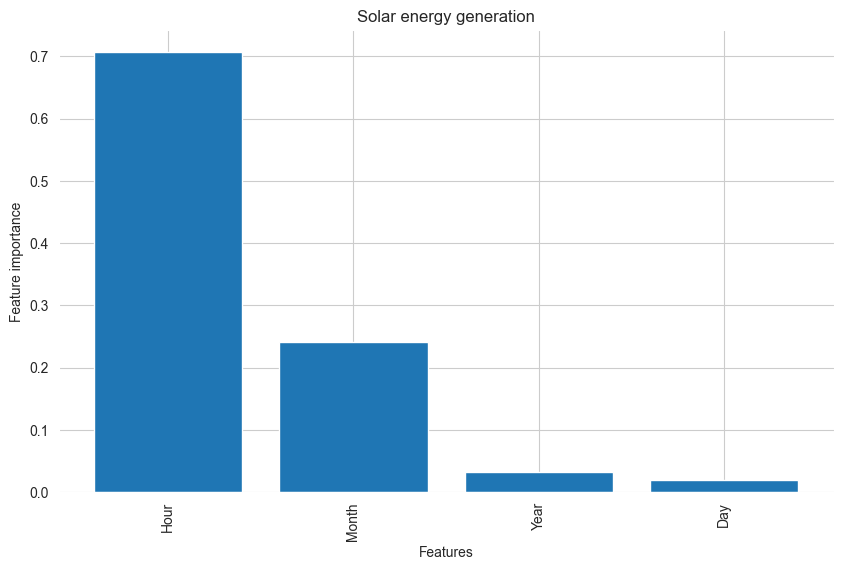

In [290]:
X_train = train[features]
X_test = test[features]
y_train = train[target]
y_test = test[target]

# Create a MinMaxScaler object
scaler = MinMaxScaler()

# Scale the features separately for training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create an XGBoost regressor
xgb_reg = xgb.XGBRegressor(n_estimators=1000, random_state=42)

# Fit the model on the scaled training data
xgb_reg.fit(X_train_scaled, y_train, eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)], early_stopping_rounds=50, verbose=True)

# Make predictions on the test set using the fitted model
test['prediction'] = xgb_reg.predict(X_test_scaled)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, test['prediction'])
mae = mean_absolute_error(y_test, test['prediction'])
rmse = mean_squared_error(y_test, test['prediction'], squared=False)
r2 = r2_score(y_test, test['prediction'])

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)

# Plot actual and predicted data
fig, ax = plt.subplots(figsize=(15,5))
df_dt[target].plot(ax=ax, color='#1f76b4', label='Actual Data')
test['prediction'].plot(ax=ax, color='red', label='Predicted Data', title=title_main + ' ' + '(Actual/predicted)')
ax.axvline('2022-01-1', color='black', label='Test/Train Split', ls='--')
ax.legend(['Actual data', 'Predicted data'])
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_ylabel(ylable_target)
ax.set_xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Calculate residuals
residuals = y_test - test['prediction']
# Create a residual plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, residuals, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('True Values')
plt.ylabel('Residuals')
plt.title(title_main)
plt.show()

#plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(y_test, test['prediction'], label=' ', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label=' ')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main)
#plt.legend()
plt.show()

fig, ax = plt.subplots(figsize=(15,5))
test['prediction'].loc[(test['prediction'].index > '2023-01-01') & (test['prediction'].index < '2023-12-01') ].plot(ax=ax, color='red', label='Predicted Data', title=title_main + ' ' + '(Actual/predicted)')
df_dt[target].loc[(df_dt[target].index > '2023-01-01') & (df_dt[target].index < '2023-12-01') ].plot(ax=ax, color='#1f76b4', label='Actual Data')
#ax.axvline('2022-01-1', color='black', label='Test/Train Split', ls='--')
ax.legend(['Actual data', 'Predicted data'])
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_ylabel(ylable_target)
ax.set_xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Get the feature importances
importances = xgb_reg.feature_importances_
# Create a list of feature names
feature_names = X_train.columns
# Sort feature importances in descending order
indices = importances.argsort()[::-1]
# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.bar(range(X_train.shape[1]), importances[indices], align='center', color='#1f76b4')
plt.xticks(range(X_train.shape[1]), feature_names[indices], rotation=90)
plt.xlabel('Features')
plt.ylabel('Feature importance')
plt.title(title_main)
plt.show()

#### XGboost with  MinMaxScaler() [for features features1= [Year', 'Month', 'Day']]

[0]	validation_0-rmse:6.07352	validation_1-rmse:9.43185
[1]	validation_0-rmse:4.71106	validation_1-rmse:7.94665
[2]	validation_0-rmse:3.82962	validation_1-rmse:6.93574
[3]	validation_0-rmse:3.29214	validation_1-rmse:6.21732
[4]	validation_0-rmse:2.97066	validation_1-rmse:5.71524


/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


[5]	validation_0-rmse:2.79044	validation_1-rmse:5.36848
[6]	validation_0-rmse:2.69581	validation_1-rmse:5.14056
[7]	validation_0-rmse:2.64470	validation_1-rmse:4.97756
[8]	validation_0-rmse:2.61469	validation_1-rmse:4.85229
[9]	validation_0-rmse:2.59959	validation_1-rmse:4.77074
[10]	validation_0-rmse:2.59047	validation_1-rmse:4.70832
[11]	validation_0-rmse:2.58555	validation_1-rmse:4.66224
[12]	validation_0-rmse:2.58287	validation_1-rmse:4.63230
[13]	validation_0-rmse:2.58133	validation_1-rmse:4.61082
[14]	validation_0-rmse:2.58044	validation_1-rmse:4.59497
[15]	validation_0-rmse:2.57980	validation_1-rmse:4.58265
[16]	validation_0-rmse:2.57932	validation_1-rmse:4.57381
[17]	validation_0-rmse:2.57889	validation_1-rmse:4.56856
[18]	validation_0-rmse:2.57863	validation_1-rmse:4.56436
[19]	validation_0-rmse:2.57851	validation_1-rmse:4.56173
[20]	validation_0-rmse:2.57838	validation_1-rmse:4.55965
[21]	validation_0-rmse:2.57817	validation_1-rmse:4.55826
[22]	validation_0-rmse:2.57805	valid

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_16399/415270448.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediction'] = xgb_reg.predict(X_test_scaled)


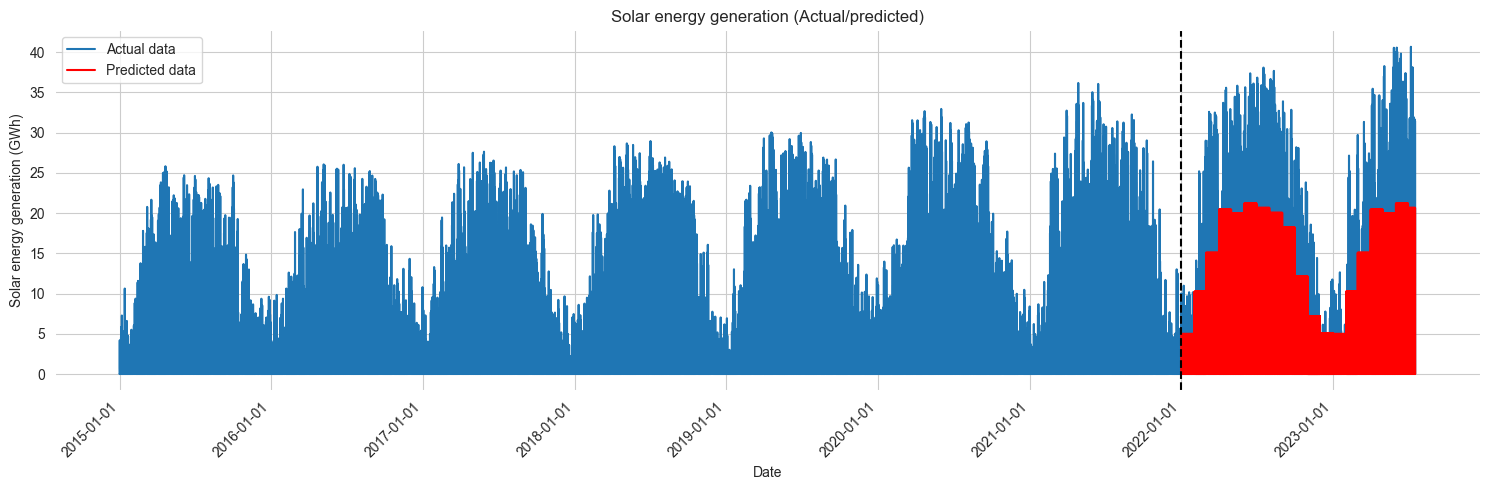

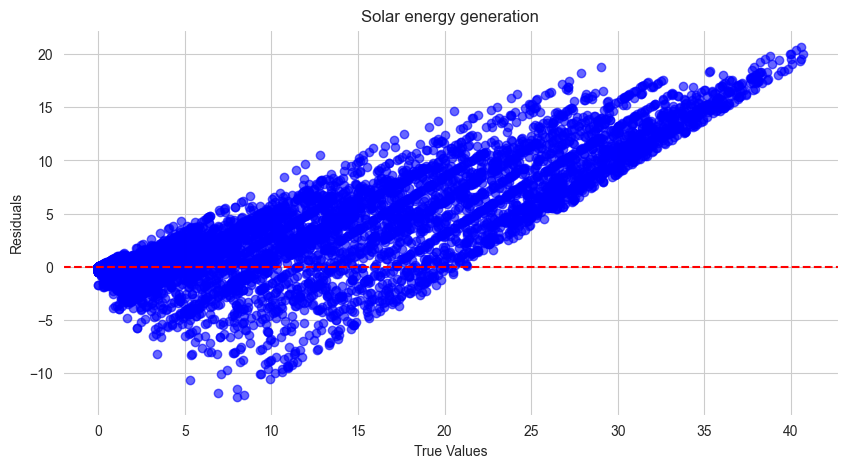

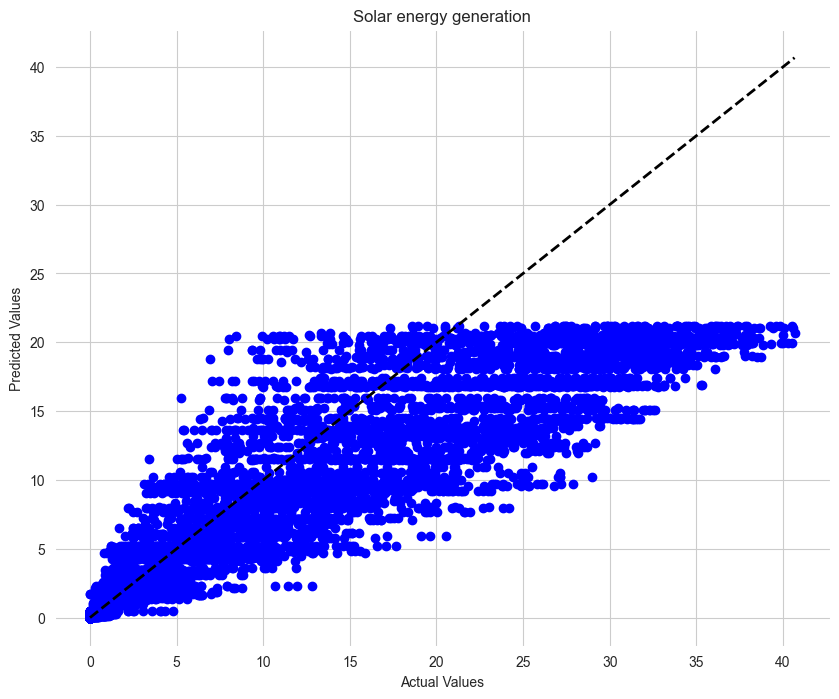

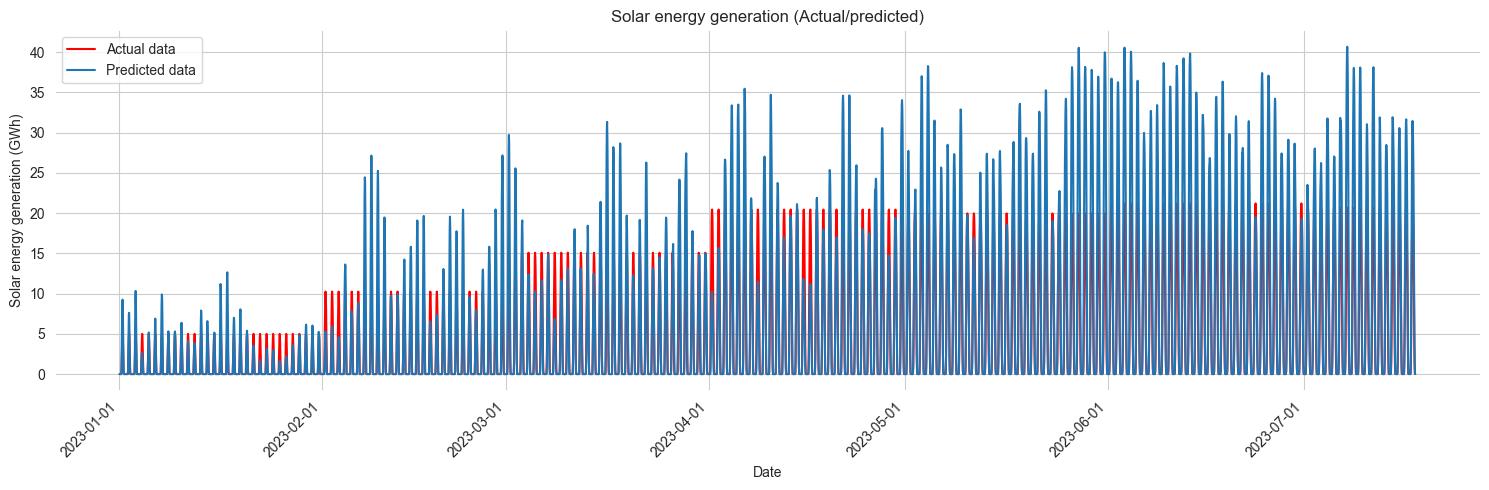

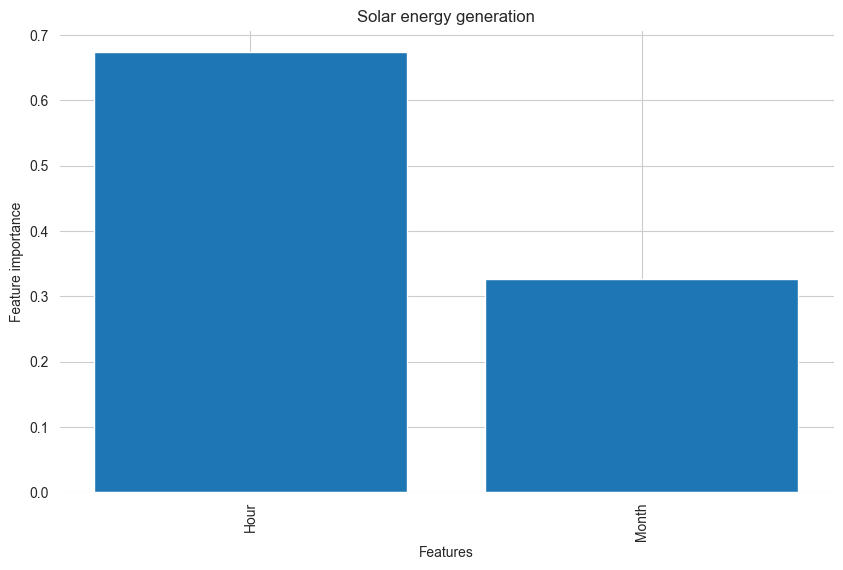

In [118]:
features1 = ['Hour', 'Month']
X_train = train[features1]
X_test = test[features1]
y_train = train[target]
y_test = test[target]

# Create a MinMaxScaler object
scaler = MinMaxScaler()

# Scale the features separately for training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create an XGBoost regressor
xgb_reg = xgb.XGBRegressor(n_estimators=1000, random_state=42)

# Fit the model on the scaled training data
xgb_reg.fit(X_train_scaled, y_train, eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)], early_stopping_rounds=50, verbose=True)

# Make predictions on the test set using the fitted model
test['prediction'] = xgb_reg.predict(X_test_scaled)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, test['prediction'])
mae = mean_absolute_error(y_test, test['prediction'])
rmse = mean_squared_error(y_test, test['prediction'], squared=False)
r2 = r2_score(y_test, test['prediction'])

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)

# Plot actual and predicted data
fig, ax = plt.subplots(figsize=(15,5))
df_dt[target].plot(ax=ax, color='#1f76b4', label='Actual Data')
test['prediction'].plot(ax=ax, color='red', label='Predicted Data', title=title_main + ' ' + '(Actual/predicted)')
ax.axvline('2022-01-1', color='black', label='Test/Train Split', ls='--')
ax.legend(['Actual data', 'Predicted data'])
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_ylabel(ylable_target)
ax.set_xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Calculate residuals
residuals = y_test - test['prediction']
# Create a residual plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, residuals, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('True Values')
plt.ylabel('Residuals')
plt.title(title_main)
plt.show()

#plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(y_test, test['prediction'], label=' ', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label=' ')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main)
#plt.legend()
plt.show()

fig, ax = plt.subplots(figsize=(15,5))
test['prediction'].loc[(test['prediction'].index > '2023-01-01') & (test['prediction'].index < '2023-12-01') ].plot(ax=ax, color='red', label='Predicted Data', title=title_main + ' ' + '(Actual/predicted)')
df_dt[target].loc[(df_dt[target].index > '2023-01-01') & (df_dt[target].index < '2023-12-01') ].plot(ax=ax, color='#1f76b4', label='Actual Data')
#ax.axvline('2022-01-1', color='black', label='Test/Train Split', ls='--')
ax.legend(['Actual data', 'Predicted data'])
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_ylabel(ylable_target)
ax.set_xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Get the feature importances
importances = xgb_reg.feature_importances_
# Create a list of feature names
feature_names = X_train.columns
# Sort feature importances in descending order
indices = importances.argsort()[::-1]
# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.bar(range(X_train.shape[1]), importances[indices], align='center', color='#1f76b4')
plt.xticks(range(X_train.shape[1]), feature_names[indices], rotation=90)
plt.xlabel('Features')
plt.ylabel('Feature importance')
plt.title(title_main)
plt.show()

####  XGboost  Grid Search 

/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in 

Best parameters found during grid search: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 1000, 'subsample': 0.8}
Mean Squared Error (MSE): 14.801405059151675
Mean Absolute Error (MAE): 2.2363132011026408
R-squared (R2): 0.8477333393002999
Root Mean Squared Error (RMSE): 3.8472594218679452


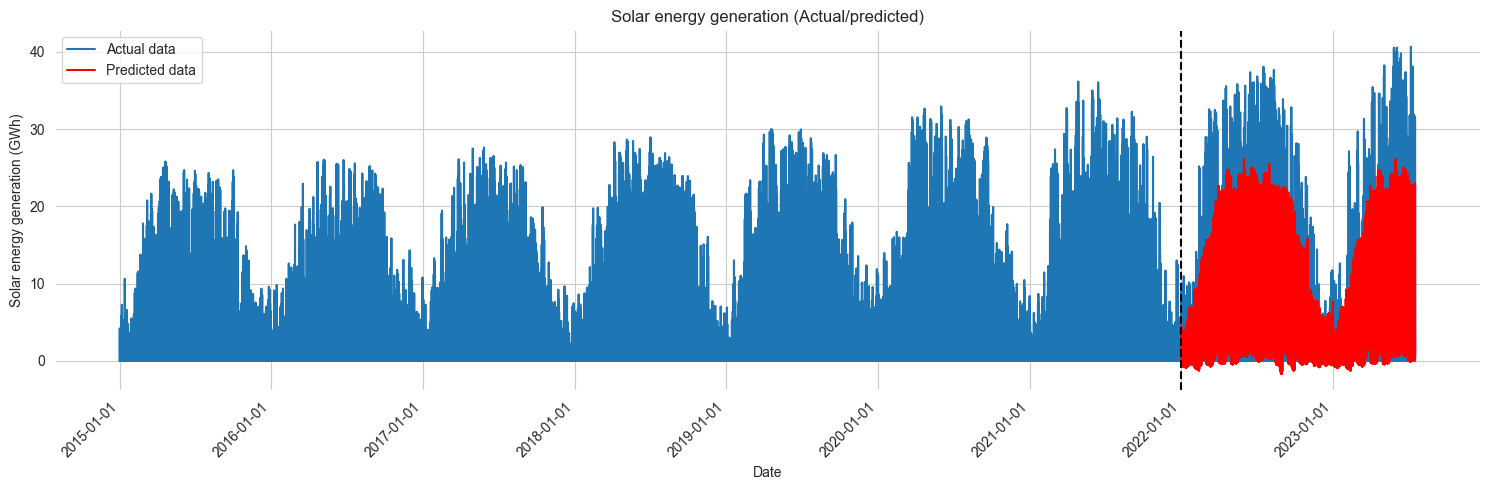

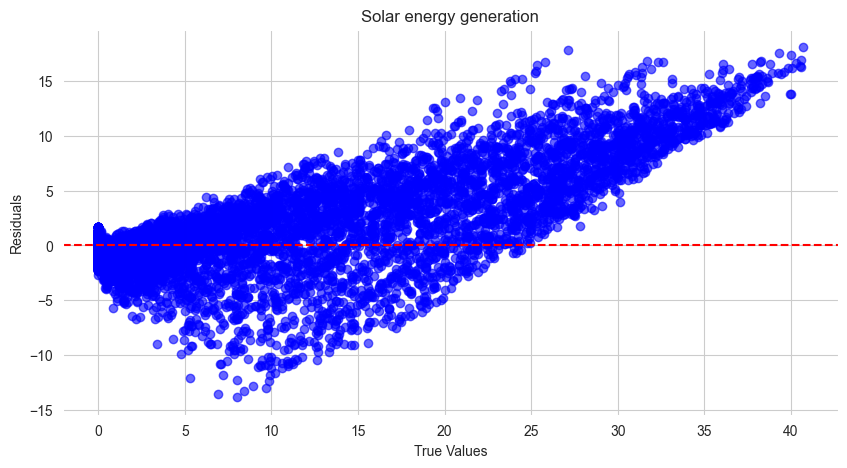

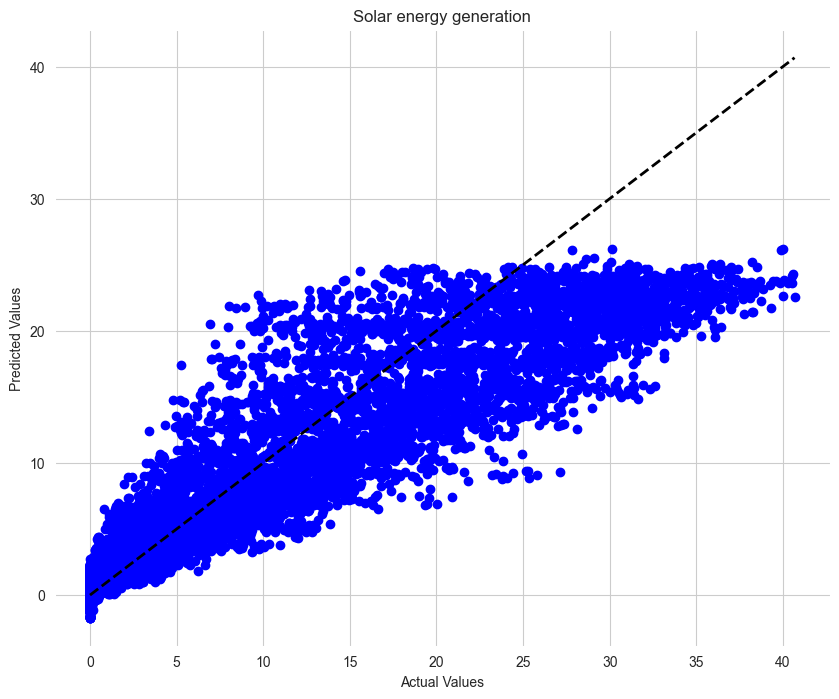

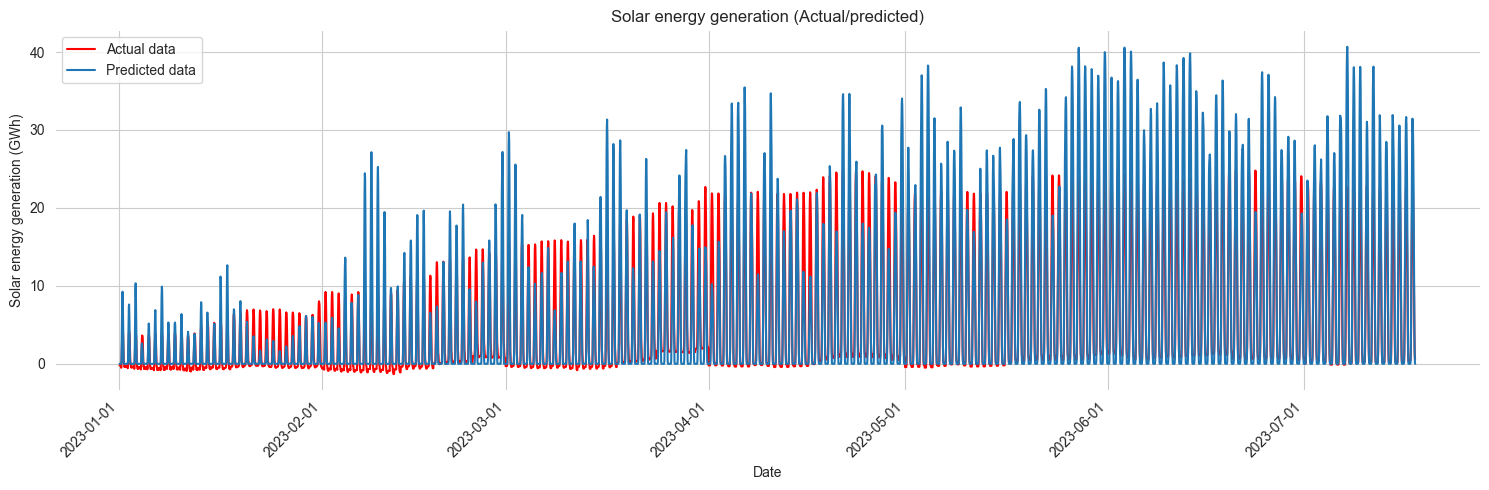

In [121]:
from sklearn.model_selection import GridSearchCV

X_train = train[features]
X_test = test[features]
y_train = train[target]
y_test = test[target]

# Create an XGBoost regressor
xgb_reg = xgb.XGBRegressor()

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 500, 1000],   # Number of boosting rounds
    'learning_rate': [0.01, 0.1, 0.2],  # Step size shrinkage to prevent overfitting
    'max_depth': [3, 5, 7],             # Maximum depth of a tree
    'subsample': [0.8, 1.0],            # Subsample ratio of the training instances
    'colsample_bytree': [0.8, 1.0]      # Subsample ratio of columns when constructing each tree
}

# Create GridSearchCV with the XGBoost regressor and parameter grid
grid_search = GridSearchCV(estimator=xgb_reg, param_grid=param_grid, scoring='neg_mean_squared_error', cv=5)

# Perform the grid search on the training data
grid_search.fit(X_train, y_train, eval_set=[(X_test, y_test)], early_stopping_rounds=50, verbose=False)

# Get the best model from the grid search
best_xgb_reg = grid_search.best_estimator_

# Make predictions on the test set using the best model
test['prediction'] = best_xgb_reg.predict(X_test)


# Calculate evaluation metrics for the best model
mse = mean_squared_error(y_test, test['prediction'])
mae = mean_absolute_error(y_test, test['prediction'])
r2 = r2_score(y_test, test['prediction'])
rmse = mean_squared_error(y_test, test['prediction'], squared=False)


print("Best parameters found during grid search:", grid_search.best_params_)
print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("R-squared (R2):", r2)
print("Root Mean Squared Error (RMSE):", rmse)


# Plot actual and predicted data
fig, ax = plt.subplots(figsize=(15,5))
df_dt[target].plot(ax=ax, color='#1f76b4', label='Actual Data')
test['prediction'].plot(ax=ax, color='red', label='Predicted Data', title=title_main + ' ' + '(Actual/predicted)')
ax.axvline('2022-01-1', color='black', label='Test/Train Split', ls='--')
ax.legend(['Actual data', 'Predicted data'])
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_ylabel(ylable_target)
ax.set_xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Calculate residuals
residuals = y_test - test['prediction']
# Create a residual plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, residuals, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('True Values')
plt.ylabel('Residuals')
plt.title(title_main)
plt.show()

#plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(y_test, test['prediction'], label=' ', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label=' ')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main)
#plt.legend()
plt.show()


fig, ax = plt.subplots(figsize=(15,5))
test['prediction'].loc[(test['prediction'].index > '2023-01-01') & (test['prediction'].index < '2023-12-01') ].plot(ax=ax, color='red', label='Predicted Data', title=title_main + ' ' + '(Actual/predicted)')
df_dt[target].loc[(df_dt[target].index > '2023-01-01') & (df_dt[target].index < '2023-12-01') ].plot(ax=ax, color='#1f76b4', label='Actual Data')
#ax.axvline('2022-01-1', color='black', label='Test/Train Split', ls='--')
ax.legend(['Actual data', 'Predicted data'])
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_ylabel(ylable_target)
ax.set_xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### XGBoost with RandomizedSearchCV

/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in 

Best parameters found during random search: {'colsample_bytree': 1.0, 'learning_rate': 0.052467822135655234, 'max_depth': 6, 'n_estimators': 376, 'subsample': 0.8}
Mean Squared Error (MSE): 14.206096747946775
Mean Absolute Error (MAE): 2.018965952163684
Root Mean Squared Error (RMSE): 3.769097603929457
R-squared (R2): 0.8538574611841141


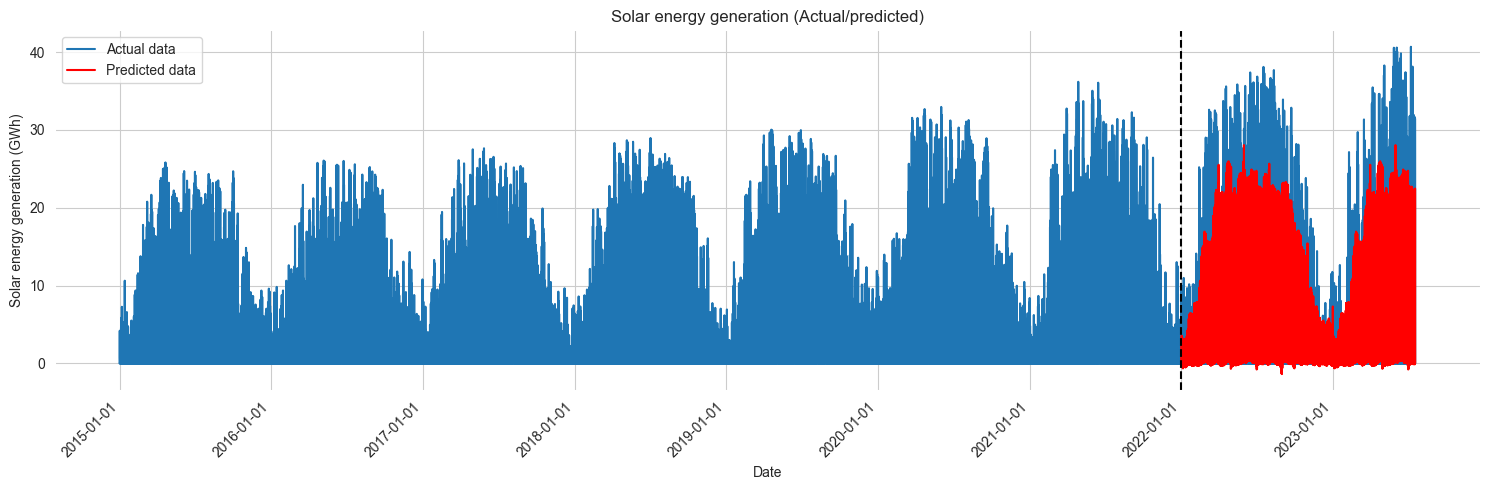

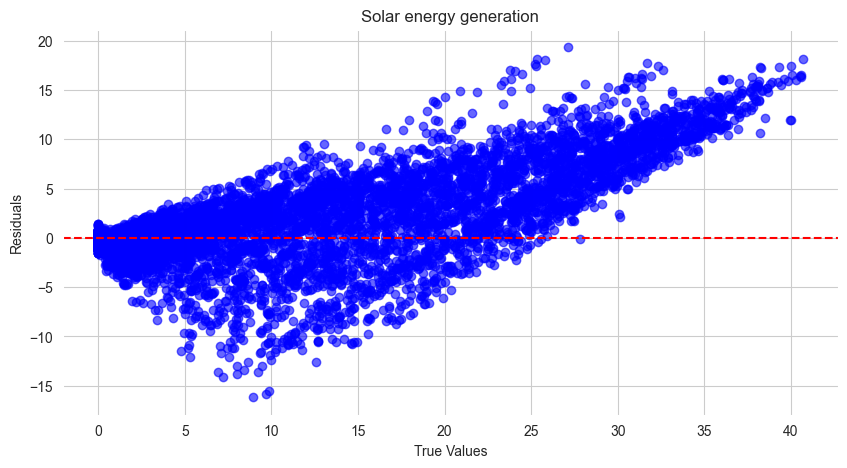

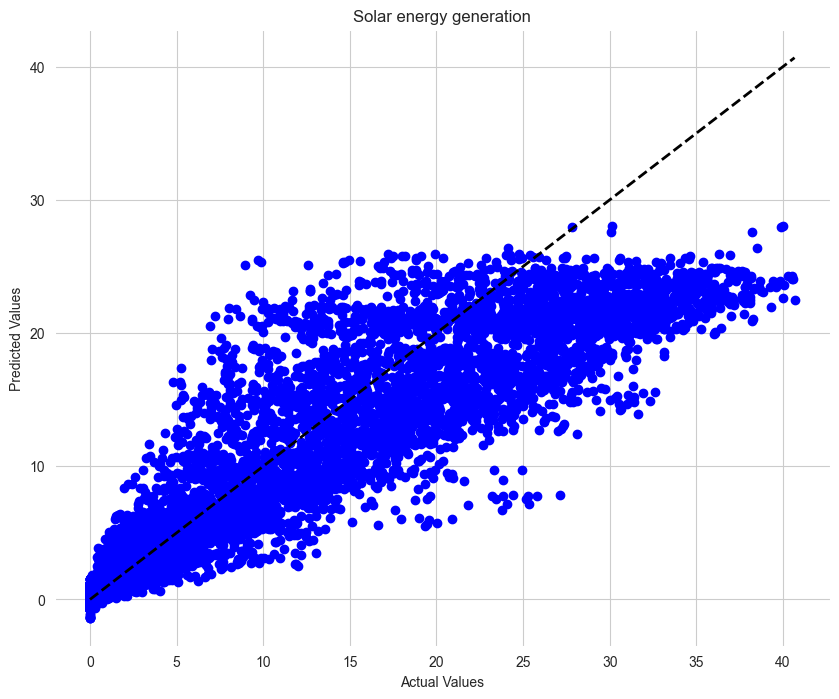

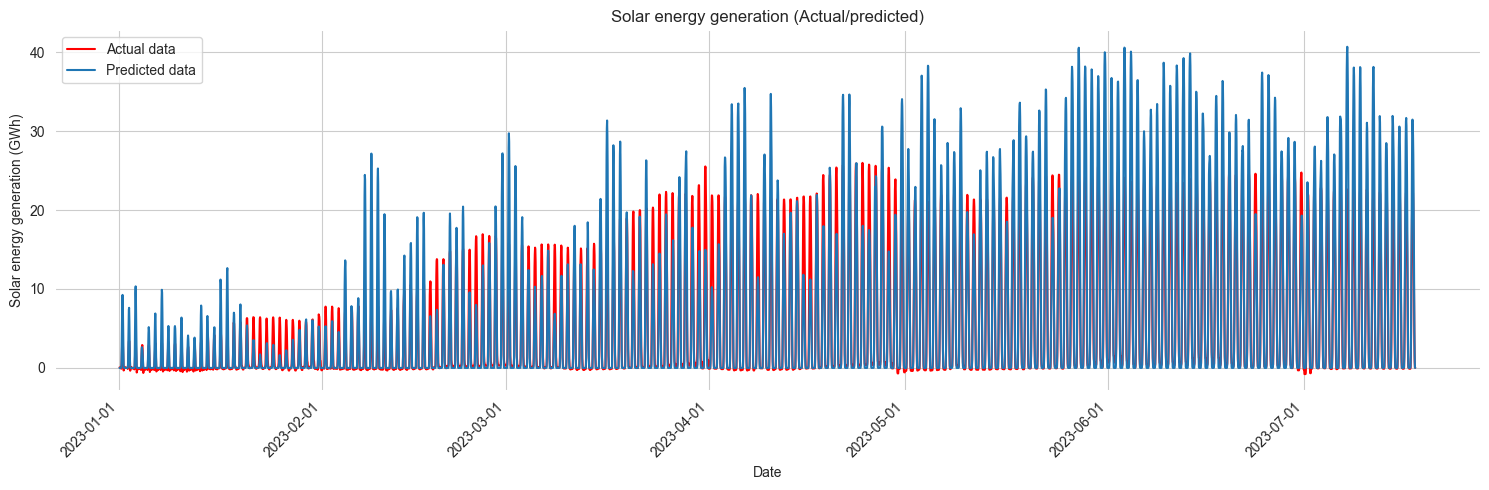

In [58]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

X_train = train[features]
X_test = test[features]
y_train = train[target]
y_test = test[target]

# Create an XGBoost regressor
xgb_reg = xgb.XGBRegressor()

# Define the parameter distribution to search
param_dist = {
    'n_estimators': randint(100, 1001),   # Number of boosting rounds
    'learning_rate': uniform(0.01, 0.2),  # Step size shrinkage to prevent overfitting
    'max_depth': randint(3, 8),           # Maximum depth of a tree
    'subsample': [0.8, 1.0],              # Subsample ratio of the training instances
    'colsample_bytree': [0.8, 1.0]        # Subsample ratio of columns when constructing each tree
}

# Create RandomizedSearchCV with the XGBoost regressor and parameter distribution
random_search = RandomizedSearchCV(estimator=xgb_reg, param_distributions=param_dist, scoring='neg_mean_squared_error', cv=5, n_iter=10, random_state=42)

# Perform the randomized grid search on the training data
random_search.fit(X_train, y_train, eval_set=[(X_test, y_test)], early_stopping_rounds=50, verbose=False)

# Get the best model from the random search
best_xgb_reg = random_search.best_estimator_

# Make predictions on the test set using the best model
test['prediction'] = best_xgb_reg.predict(X_test)

# Calculate evaluation metrics for the best model
mse = mean_squared_error(y_test, test['prediction'])
mae = mean_absolute_error(y_test, test['prediction'])
rmse = mean_squared_error(y_test, test['prediction'], squared=False)
r2 = r2_score(y_test, test['prediction'])

print("Best parameters found during random search:", random_search.best_params_)
print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)

# Plot actual and predicted data
fig, ax = plt.subplots(figsize=(15,5))
df_dt[target].plot(ax=ax, color='#1f76b4', label='Actual Data')
test['prediction'].plot(ax=ax, color='red', label='Predicted Data', title=title_main + ' ' + '(Actual/predicted)')
ax.axvline('2022-01-1', color='black', label='Test/Train Split', ls='--')
ax.legend(['Actual data', 'Predicted data'])
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_ylabel(ylable_target)
ax.set_xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Calculate residuals
residuals = y_test - test['prediction']
# Create a residual plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, residuals, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('True Values')
plt.ylabel('Residuals')
plt.title(title_main)
plt.show()

#plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(y_test, test['prediction'], label=' ', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label=' ')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main)
#plt.legend()
plt.show()


fig, ax = plt.subplots(figsize=(15,5))
test['prediction'].loc[(test['prediction'].index > '2023-01-01') & (test['prediction'].index < '2023-12-01') ].plot(ax=ax, color='red', label='Predicted Data', title=title_main + ' ' + '(Actual/predicted)')
df_dt[target].loc[(df_dt[target].index > '2023-01-01') & (df_dt[target].index < '2023-12-01') ].plot(ax=ax, color='#1f76b4', label='Actual Data')
#ax.axvline('2022-01-1', color='black', label='Test/Train Split', ls='--')
ax.legend(['Actual data', 'Predicted data'])
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_ylabel(ylable_target)
ax.set_xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## RandomForestRegressort with  MinMaxScaler()

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_13075/545168146.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediction'] = rf_reg.predict(X_test_scaled)


Mean Squared Error (MSE): 18.334628421538532
Mean Absolute Error (MAE): 2.0843675044411545
Root Mean Squared Error (RMSE): 4.28189542393769
R-squared (R2): 0.8113859708750183


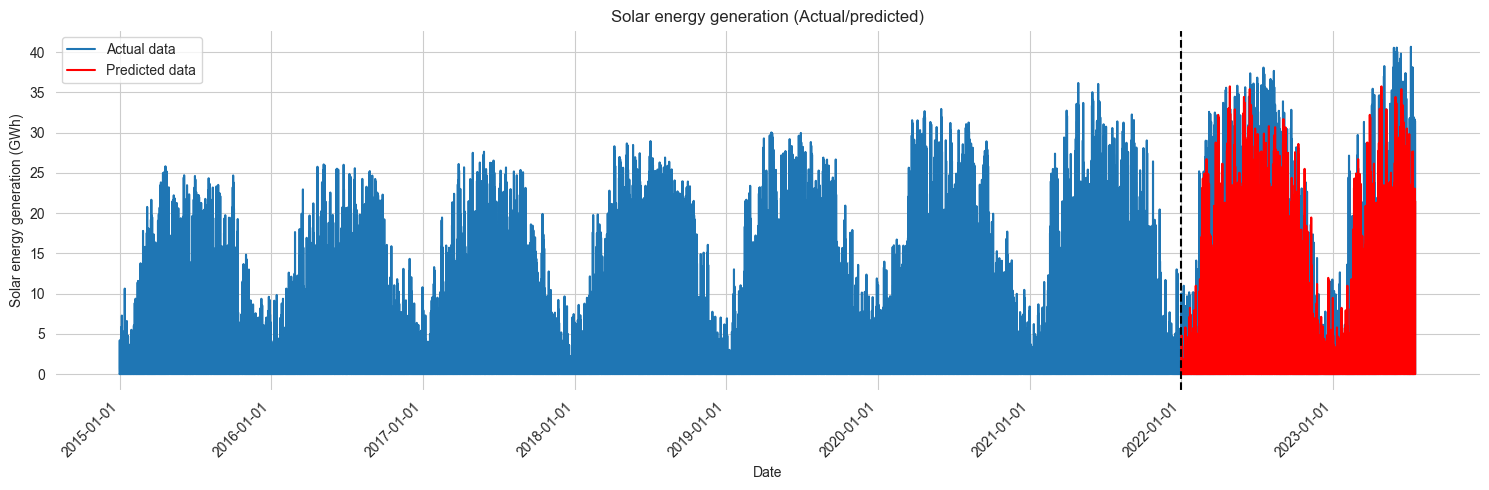

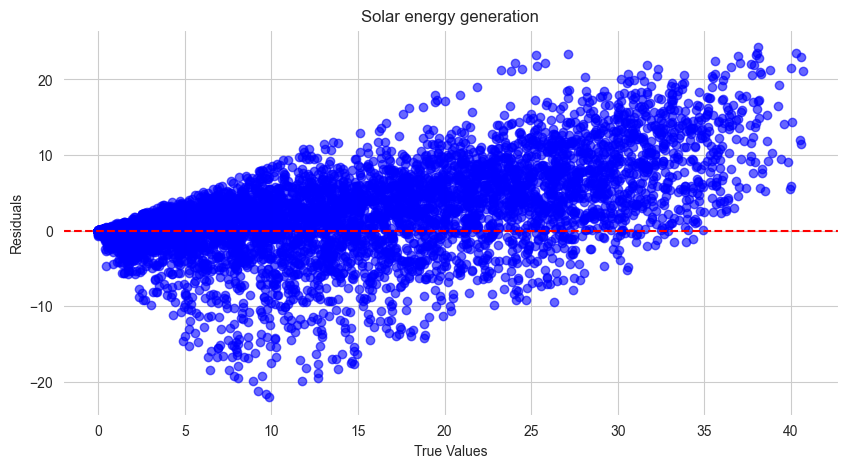

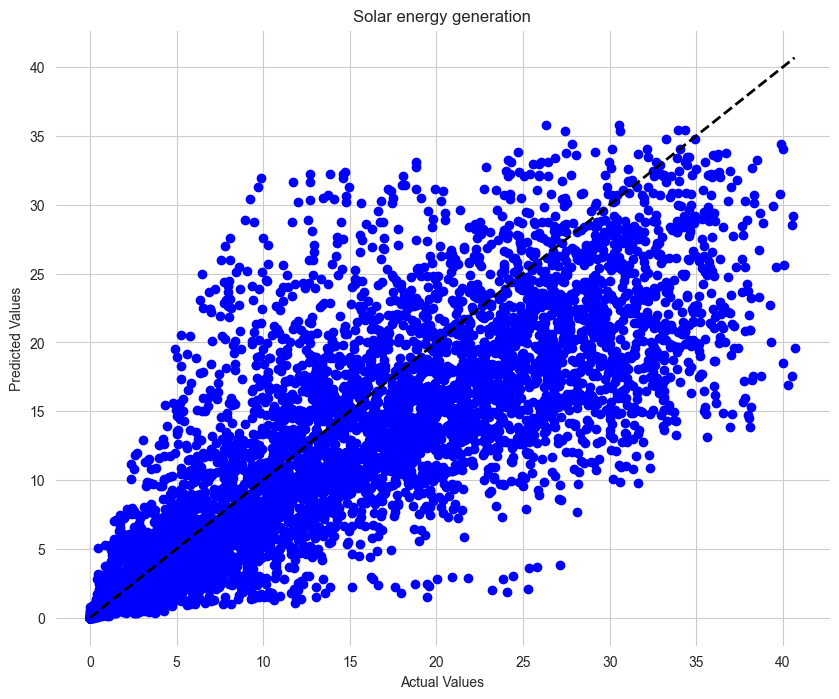

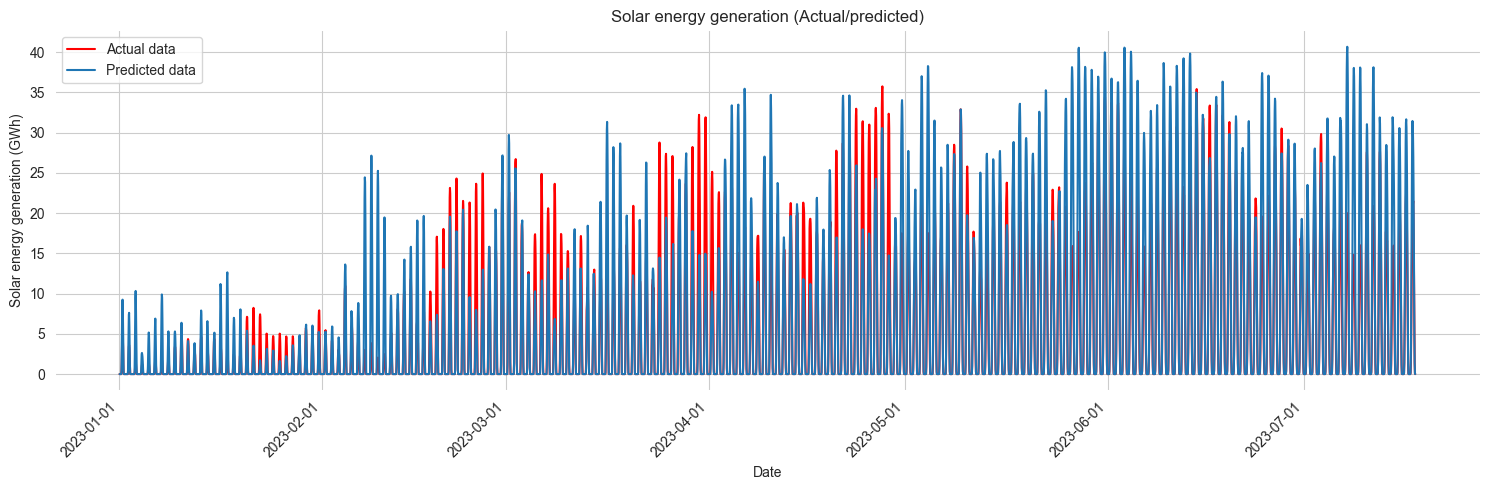

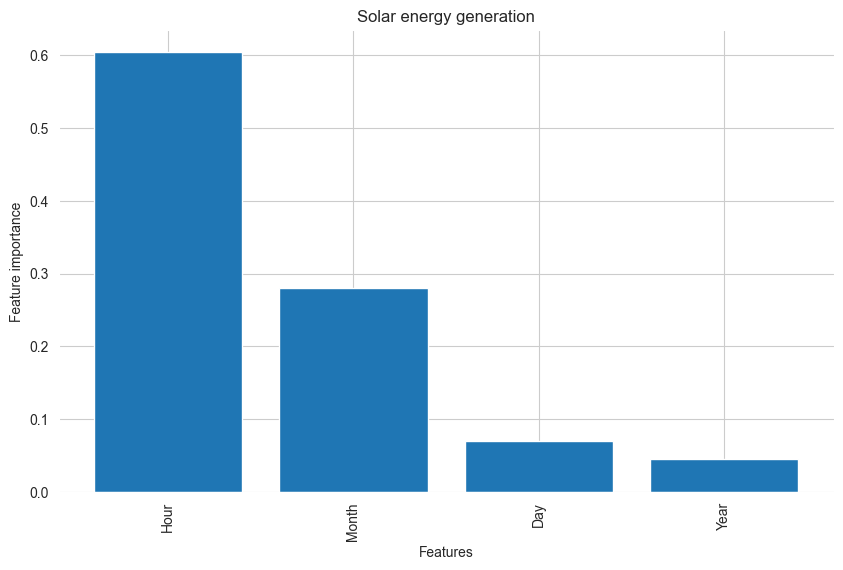

In [295]:
# Extract features and target variables
X_train = train[features]
X_test = test[features]
y_train = train[target]
y_test = test[target]

# Create a MinMaxScaler object
scaler = MinMaxScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create a Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=1000, random_state=42)

# Fit the model on the scaled training data
rf_reg.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
test['prediction'] = rf_reg.predict(X_test_scaled)

# Calculate evaluation metrics on the unscaled predictions
mse = mean_squared_error(y_test, test['prediction'])
mae = mean_absolute_error(y_test, test['prediction'])
rmse = mean_squared_error(y_test, test['prediction'], squared=False)
r2 = r2_score(y_test, test['prediction'])

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)


# Plot actual and predicted data
fig, ax = plt.subplots(figsize=(15,5))
df_dt[target].plot(ax=ax, color='#1f76b4', label='Actual Data')
test['prediction'].plot(ax=ax, color='red', label='Predicted Data', title=title_main + ' ' + '(Actual/predicted)')
ax.axvline('2022-01-1', color='black', label='Test/Train Split', ls='--')
ax.legend(['Actual data', 'Predicted data'])
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_ylabel(ylable_target)
ax.set_xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Calculate residuals
residuals = y_test - test['prediction']
# Create a residual plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, residuals, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('True Values')
plt.ylabel('Residuals')
plt.title(title_main)
plt.show()

#plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(y_test, test['prediction'], label=' ', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label=' ')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main)
#plt.legend()
plt.show()


fig, ax = plt.subplots(figsize=(15,5))
test['prediction'].loc[(test['prediction'].index > '2023-01-01') & (test['prediction'].index < '2023-12-01') ].plot(ax=ax, color='red', label='Predicted Data', title=title_main + ' ' + '(Actual/predicted)')
df_dt[target].loc[(df_dt[target].index > '2023-01-01') & (df_dt[target].index < '2023-12-01') ].plot(ax=ax, color='#1f76b4', label='Actual Data')
#ax.axvline('2022-01-1', color='black', label='Test/Train Split', ls='--')
ax.legend(['Actual data', 'Predicted data'])
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_ylabel(ylable_target)
ax.set_xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Get the feature importances
importances = rf_reg.feature_importances_
# Create a list of feature names
feature_names = X_train.columns
# Sort feature importances in descending order
indices = importances.argsort()[::-1]
# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.bar(range(X_train.shape[1]), importances[indices], align='center', color='#1f76b4')
plt.xticks(range(X_train.shape[1]), feature_names[indices], rotation=90)
plt.xlabel('Features')
plt.ylabel('Feature importance')
plt.title(title_main)
plt.show()


#### Random forest with specfic features

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_16399/624335735.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediction'] = rf_reg.predict(X_test_scaled)


Mean Squared Error (MSE): 20.746688362262876
Mean Absolute Error (MAE): 2.307860944397903
Root Mean Squared Error (RMSE): 4.554853275602067
R-squared (R2): 0.7865723595243496


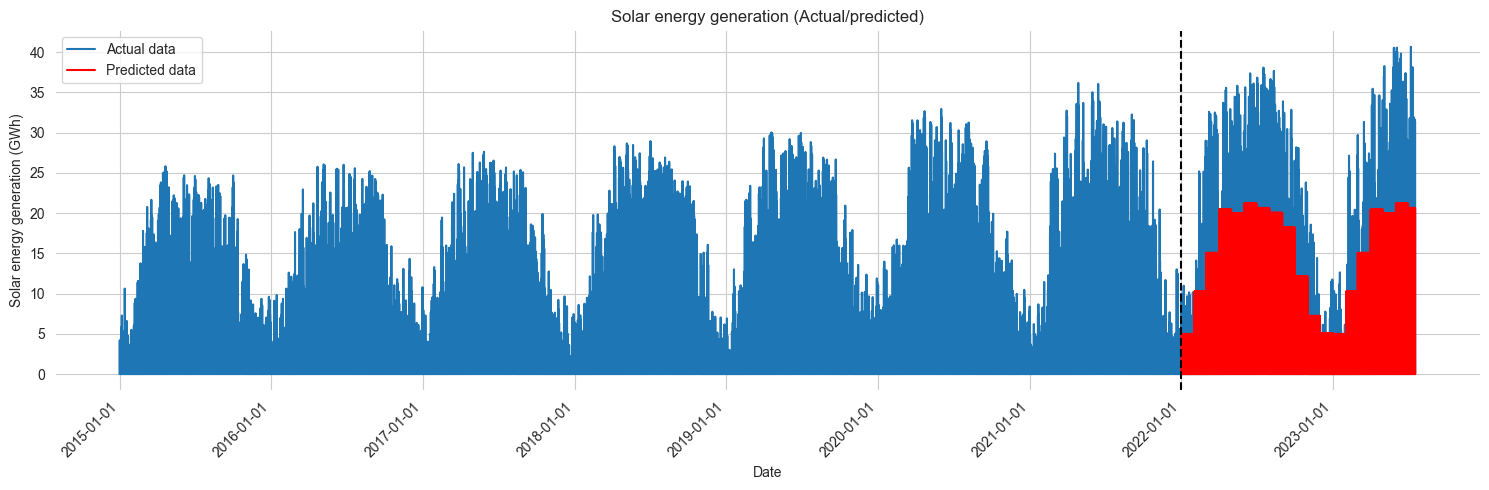

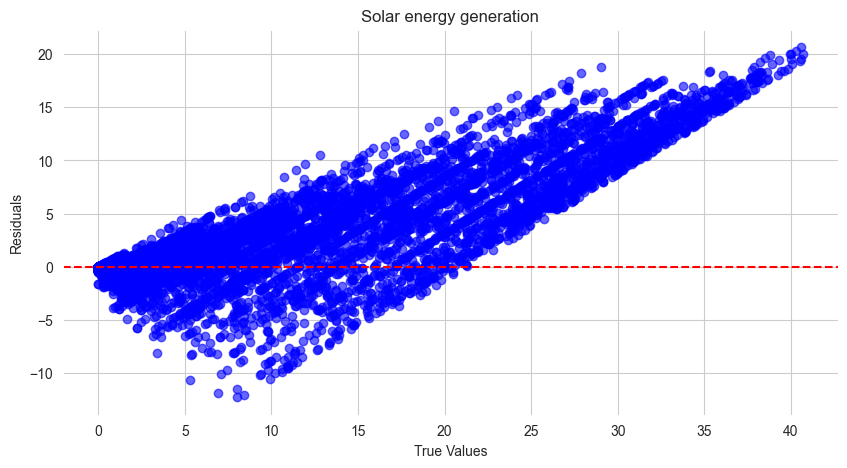

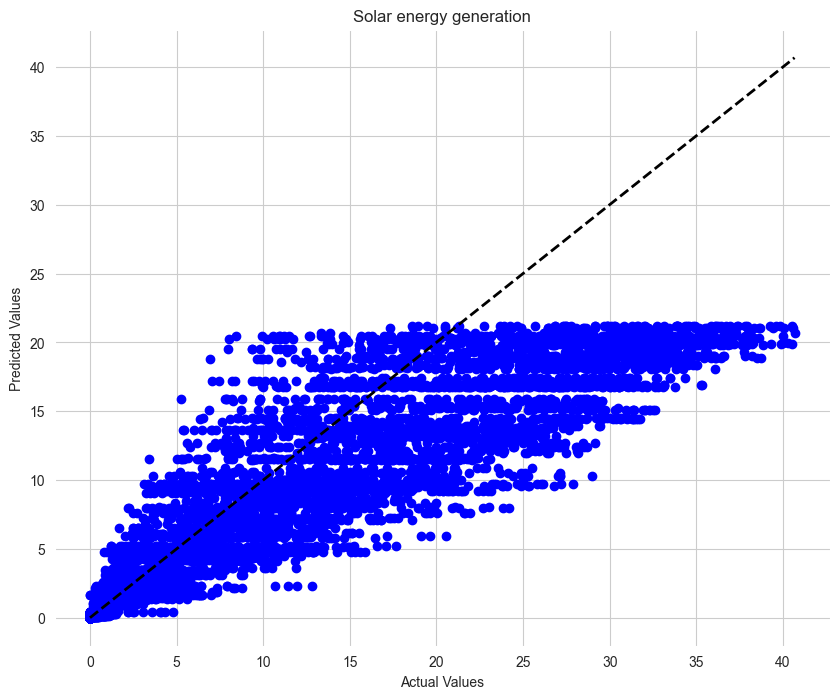

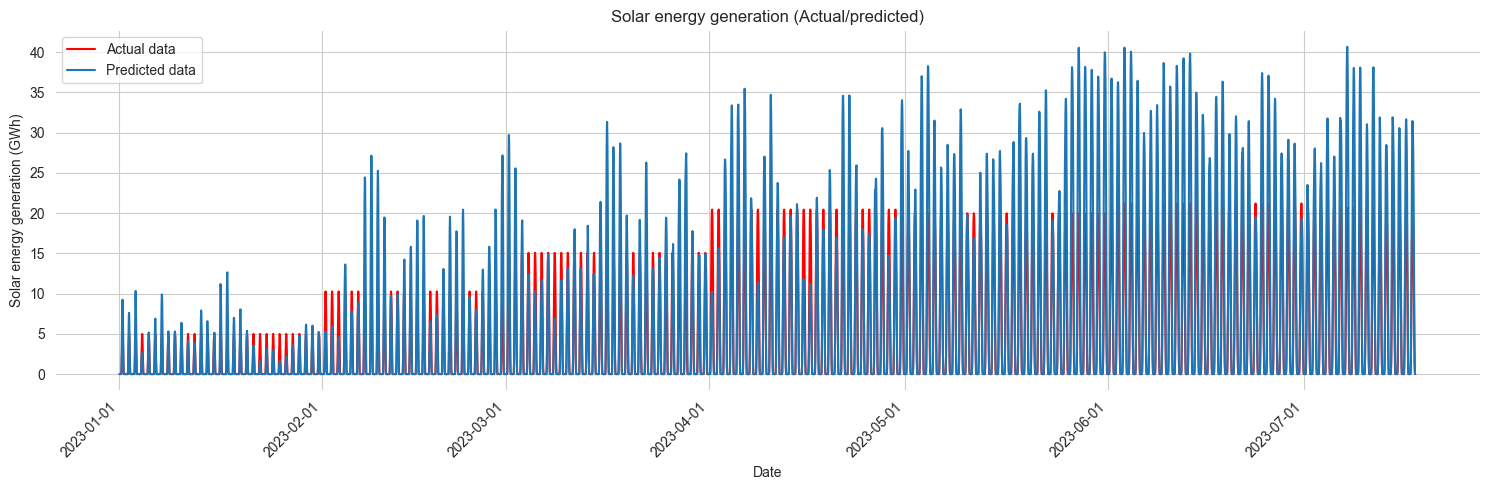

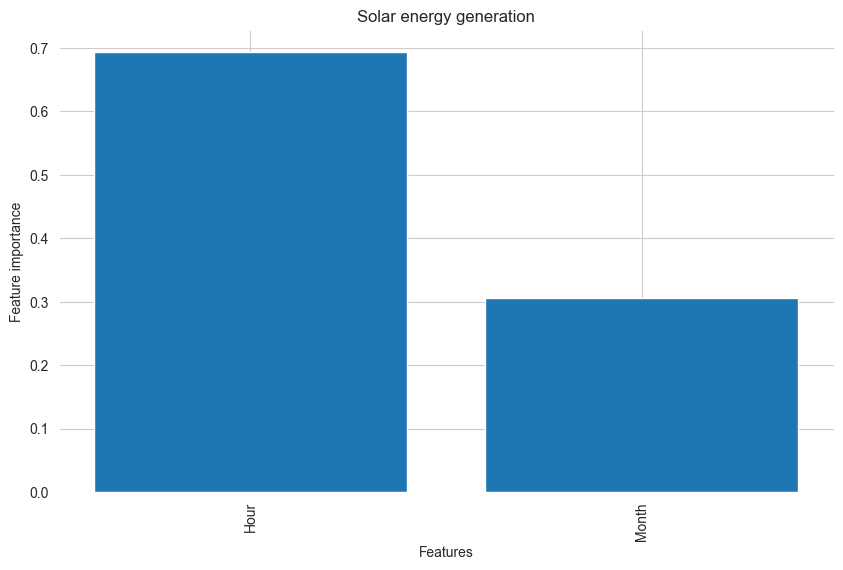

In [120]:
# Extract features and target variables

features1 = ['Month', 'Hour']
X_train = train[features1]
X_test = test[features1]
y_train = train[target]
y_test = test[target]

# Create a MinMaxScaler object
scaler = MinMaxScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create a Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=1000, random_state=42)

# Fit the model on the scaled training data
rf_reg.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
test['prediction'] = rf_reg.predict(X_test_scaled)

# Calculate evaluation metrics on the unscaled predictions
mse = mean_squared_error(y_test, test['prediction'])
mae = mean_absolute_error(y_test, test['prediction'])
rmse = mean_squared_error(y_test, test['prediction'], squared=False)
r2 = r2_score(y_test, test['prediction'])

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)


# Plot actual and predicted data
fig, ax = plt.subplots(figsize=(15,5))
df_dt[target].plot(ax=ax, color='#1f76b4', label='Actual Data')
test['prediction'].plot(ax=ax, color='red', label='Predicted Data', title=title_main + ' ' + '(Actual/predicted)')
ax.axvline('2022-01-1', color='black', label='Test/Train Split', ls='--')
ax.legend(['Actual data', 'Predicted data'])
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_ylabel(ylable_target)
ax.set_xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Calculate residuals
residuals = y_test - test['prediction']
# Create a residual plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, residuals, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('True Values')
plt.ylabel('Residuals')
plt.title(title_main)
plt.show()

#plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(y_test, test['prediction'], label=' ', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label=' ')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main)
#plt.legend()
plt.show()


fig, ax = plt.subplots(figsize=(15,5))
test['prediction'].loc[(test['prediction'].index > '2023-01-01') & (test['prediction'].index < '2023-12-01') ].plot(ax=ax, color='red', label='Predicted Data', title=title_main + ' ' + '(Actual/predicted)')
df_dt[target].loc[(df_dt[target].index > '2023-01-01') & (df_dt[target].index < '2023-12-01') ].plot(ax=ax, color='#1f76b4', label='Actual Data')
#ax.axvline('2022-01-1', color='black', label='Test/Train Split', ls='--')
ax.legend(['Actual data', 'Predicted data'])
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_ylabel(ylable_target)
ax.set_xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Get the feature importances
importances = rf_reg.feature_importances_
# Create a list of feature names
feature_names = X_train.columns
# Sort feature importances in descending order
indices = importances.argsort()[::-1]
# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.bar(range(X_train.shape[1]), importances[indices], align='center', color='#1f76b4')
plt.xticks(range(X_train.shape[1]), feature_names[indices], rotation=90)
plt.xlabel('Features')
plt.ylabel('Feature importance')
plt.title(title_main)
plt.show()


#### Grid search for Random forest 

Fitting 5 folds for each of 108 candidates, totalling 540 fits


/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_16399/3626913871.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediction'] = best_rf_reg.predict(X_test_scaled)


Best parameters found during grid search: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 1000}
Mean Squared Error (MSE): 16.45429286301581
Mean Absolute Error (MAE): 2.0286751186569165
Root Mean Squared Error (RMSE): 4.056389140974496
R-squared (R2): 0.8307295680096791


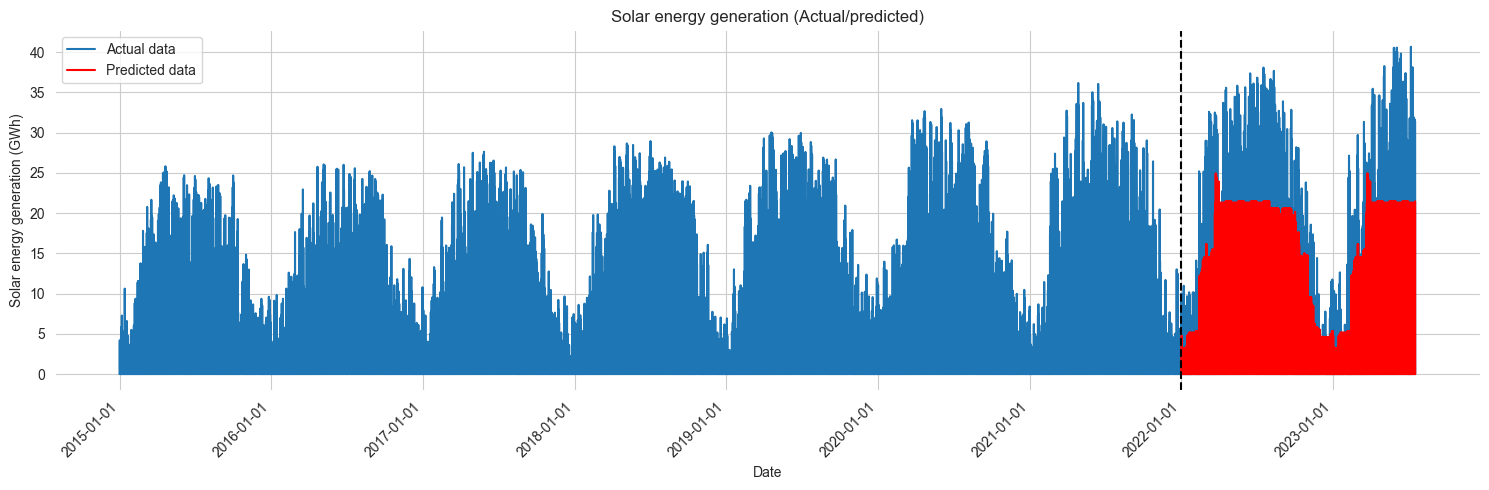

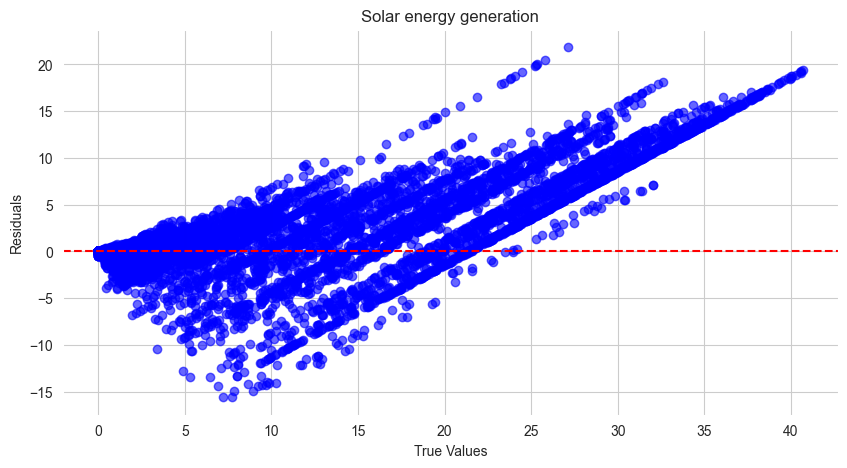

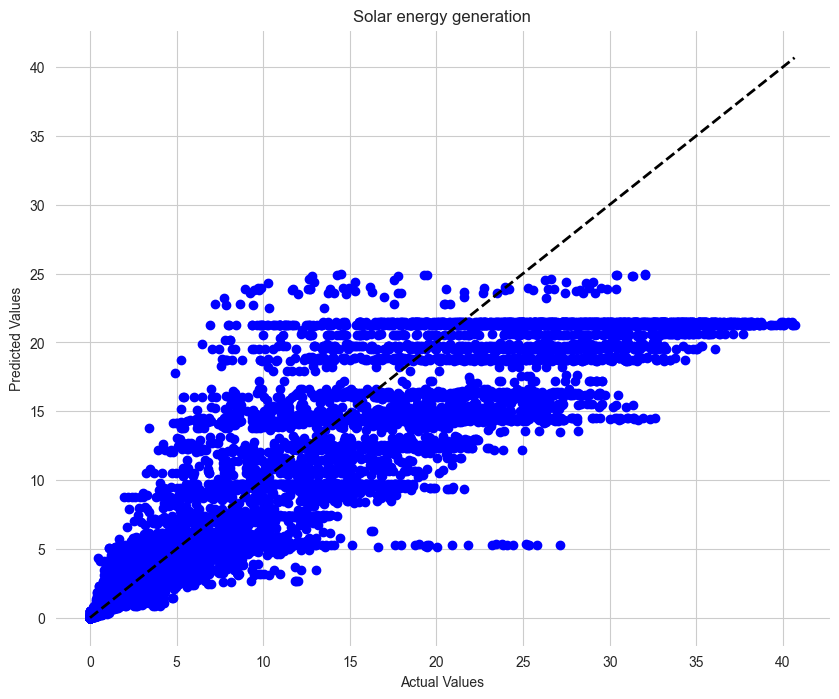

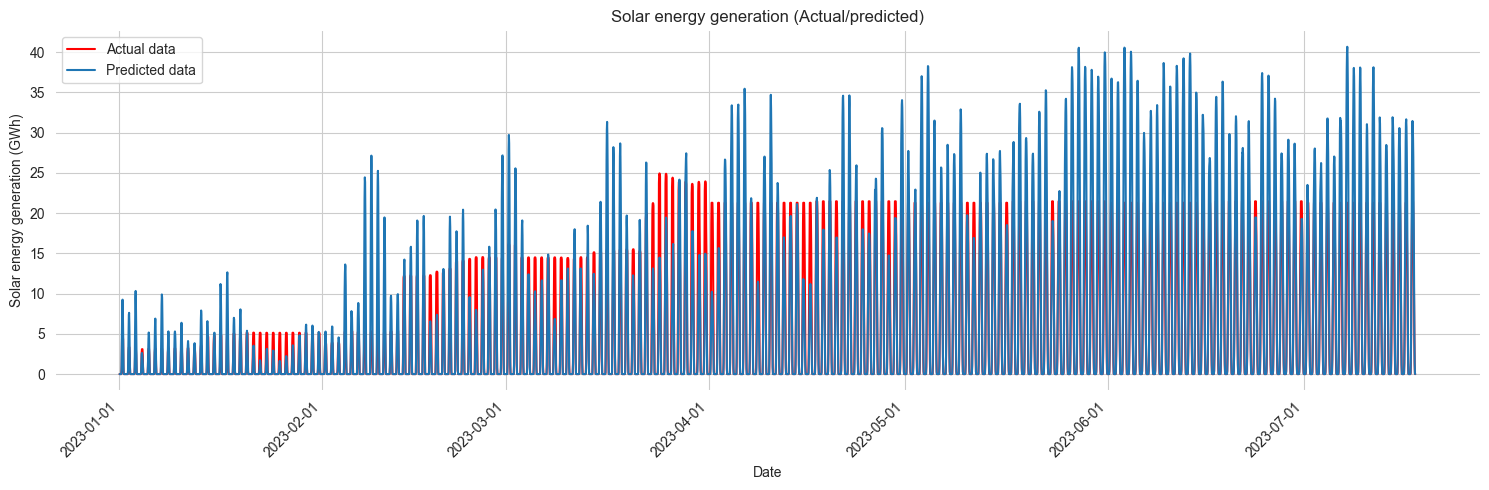

In [56]:
from sklearn.model_selection import GridSearchCV
# Extract features and target variables
X_train = train[features]
X_test = test[features]
y_train = train[target]
y_test = test[target]

# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create a Random Forest Regressor
rf_reg = RandomForestRegressor(random_state=42)

# Define hyperparameters for the grid search
param_grid = {
    'n_estimators': [100, 500, 1000],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create a GridSearchCV object
grid_search = GridSearchCV(estimator=rf_reg, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)

# Fit the grid search on the scaled training data
grid_search.fit(X_train_scaled, y_train)

# Get the best model from the grid search
best_rf_reg = grid_search.best_estimator_

# Make predictions on the scaled test set
test['prediction'] = best_rf_reg.predict(X_test_scaled)

# Calculate evaluation metrics on the unscaled predictions
mse = mean_squared_error(y_test, test['prediction'])
mae = mean_absolute_error(y_test, test['prediction'])
rmse = mean_squared_error(y_test, test['prediction'], squared=False)
r2 = r2_score(y_test, test['prediction'])

print("Best parameters found during grid search:", grid_search.best_params_)
print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)


# Plot actual and predicted data
fig, ax = plt.subplots(figsize=(15,5))
df_dt[target].plot(ax=ax, color='#1f76b4', label='Actual Data')
test['prediction'].plot(ax=ax, color='red', label='Predicted Data', title=title_main + ' ' + '(Actual/predicted)')
ax.axvline('2022-01-1', color='black', label='Test/Train Split', ls='--')
ax.legend(['Actual data', 'Predicted data'])
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_ylabel(ylable_target)
ax.set_xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Calculate residuals
residuals = y_test - test['prediction']
# Create a residual plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, residuals, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('True Values')
plt.ylabel('Residuals')
plt.title(title_main)
plt.show()

#plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(y_test, test['prediction'], label=' ', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label=' ')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main)
#plt.legend()
plt.show()


fig, ax = plt.subplots(figsize=(15,5))
test['prediction'].loc[(test['prediction'].index > '2023-01-01') & (test['prediction'].index < '2023-12-01') ].plot(ax=ax, color='red', label='Predicted Data', title=title_main + ' ' + '(Actual/predicted)')
df_dt[target].loc[(df_dt[target].index > '2023-01-01') & (df_dt[target].index < '2023-12-01') ].plot(ax=ax, color='#1f76b4', label='Actual Data')
#ax.axvline('2022-01-1', color='black', label='Test/Train Split', ls='--')
ax.legend(['Actual data', 'Predicted data'])
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_ylabel(ylable_target)
ax.set_xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### RandomizedSearchCV search for Random forest 

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_16399/3516024349.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediction'] = best_rf_reg.predict(X_test_scaled)


Best parameters found during random search: {'n_estimators': 1000, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 10}
Mean Squared Error (MSE): 16.455187711578773
Mean Absolute Error (MAE): 2.0284696636678246
Root Mean Squared Error (RMSE): 4.056499440598849
R-squared (R2): 0.8307203624239952


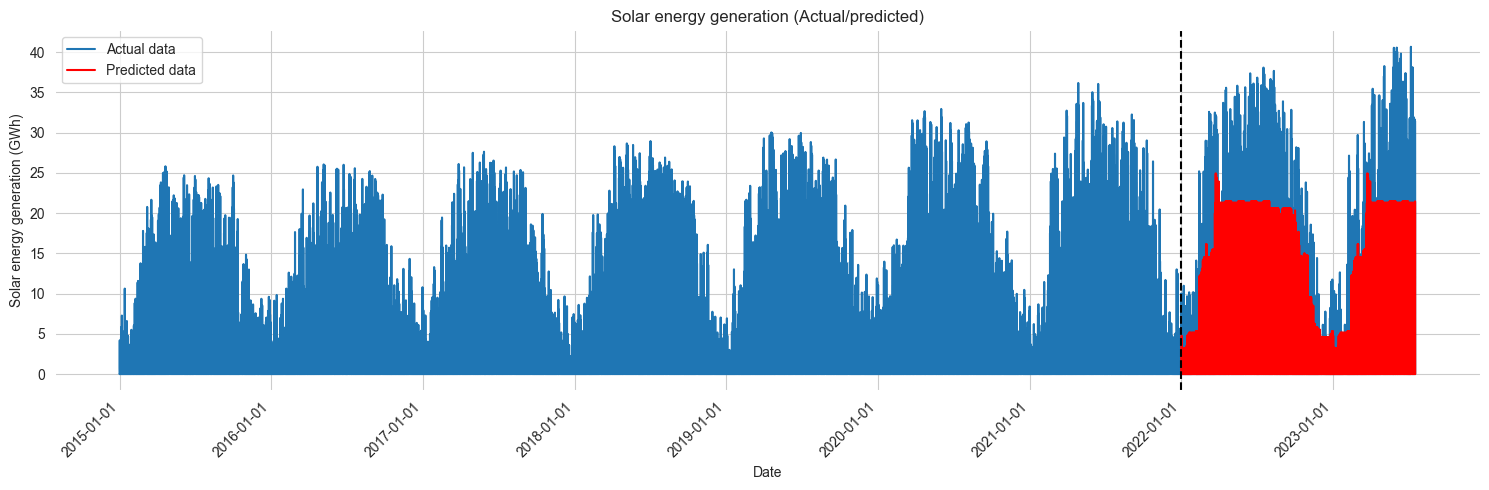

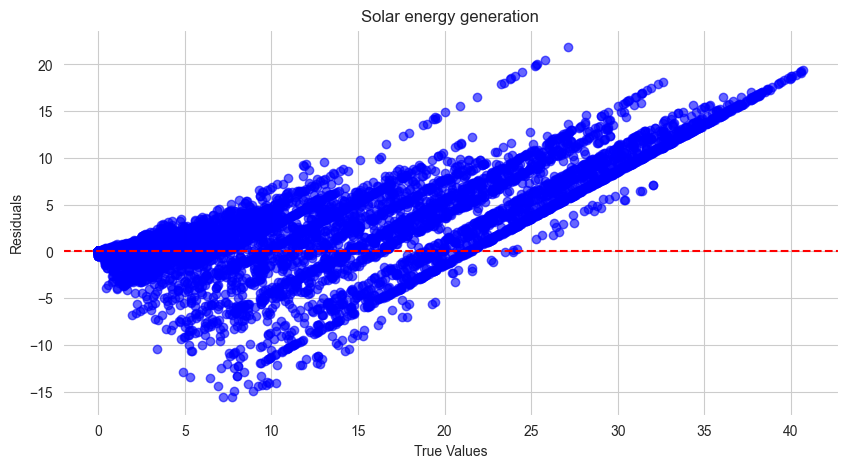

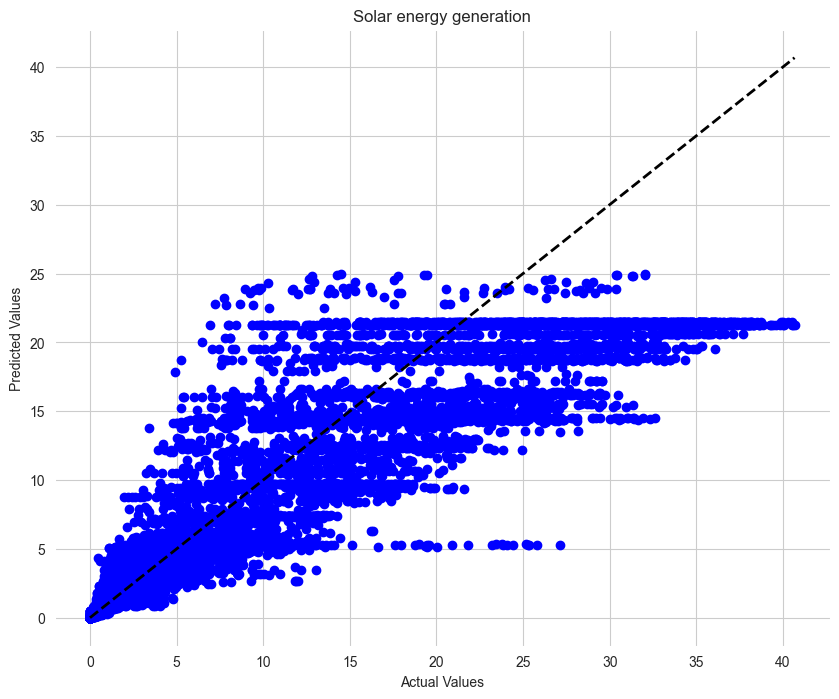

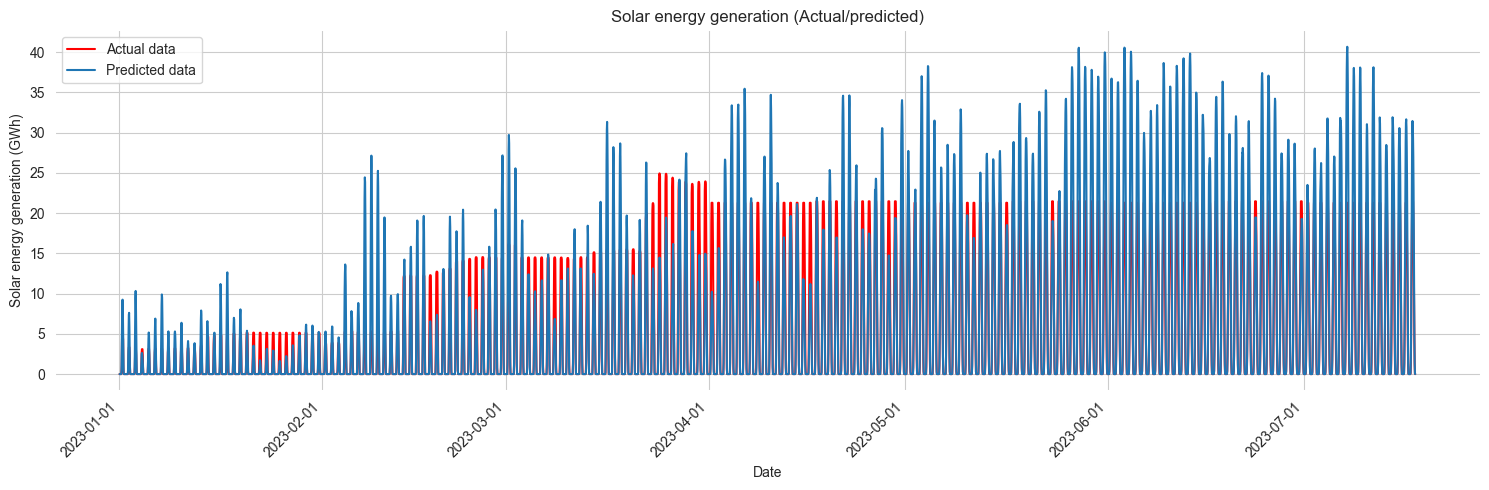

In [57]:
from sklearn.model_selection import RandomizedSearchCV

# Extract features and target variables
X_train = train[features]
X_test = test[features]
y_train = train[target]
y_test = test[target]

# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create a Random Forest Regressor
rf_reg = RandomForestRegressor(random_state=42)

# Define hyperparameters for the random search
param_dist = {
    'n_estimators': [100, 500, 1000],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create a RandomizedSearchCV object
random_search = RandomizedSearchCV(estimator=rf_reg, param_distributions=param_dist, n_iter=10, cv=5, n_jobs=-1, random_state=42, verbose=1)

# Fit the random search on the scaled training data
random_search.fit(X_train_scaled, y_train)

# Get the best model from the random search
best_rf_reg = random_search.best_estimator_

# Make predictions on the scaled test set
test['prediction'] = best_rf_reg.predict(X_test_scaled)

# Calculate evaluation metrics on the unscaled predictions
mse = mean_squared_error(y_test, test['prediction'])
mae = mean_absolute_error(y_test, test['prediction'])
rmse = mean_squared_error(y_test, test['prediction'], squared=False)
r2 = r2_score(y_test, test['prediction'])

print("Best parameters found during random search:", random_search.best_params_)
print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)


# Plot actual and predicted data
fig, ax = plt.subplots(figsize=(15,5))
df_dt[target].plot(ax=ax, color='#1f76b4', label='Actual Data')
test['prediction'].plot(ax=ax, color='red', label='Predicted Data', title=title_main + ' ' + '(Actual/predicted)')
ax.axvline('2022-01-1', color='black', label='Test/Train Split', ls='--')
ax.legend(['Actual data', 'Predicted data'])
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_ylabel(ylable_target)
ax.set_xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Calculate residuals
residuals = y_test - test['prediction']
# Create a residual plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, residuals, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('True Values')
plt.ylabel('Residuals')
plt.title(title_main)
plt.show()

#plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(y_test, test['prediction'], label=' ', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label=' ')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main)
#plt.legend()
plt.show()


fig, ax = plt.subplots(figsize=(15,5))
test['prediction'].loc[(test['prediction'].index > '2023-01-01') & (test['prediction'].index < '2023-12-01') ].plot(ax=ax, color='red', label='Predicted Data', title=title_main + ' ' + '(Actual/predicted)')
df_dt[target].loc[(df_dt[target].index > '2023-01-01') & (df_dt[target].index < '2023-12-01') ].plot(ax=ax, color='#1f76b4', label='Actual Data')
#ax.axvline('2022-01-1', color='black', label='Test/Train Split', ls='--')
ax.legend(['Actual data', 'Predicted data'])
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_ylabel(ylable_target)
ax.set_xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



